
Processing C203_25...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 25 customers (requested: 25)
Successfully loaded C203_25:
  - Number of customers: 25
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=300, E=10
Starting greedy construction for 25 customers...
Vehicle 1: Starting from depot, remaining customers: 25
  Added customer 20, remaining: 24
  Added customer 22, remaining: 23
  Added customer 24, remaining: 22
  Added customer 21, remaining: 21
  Added customer 5, remaining: 20
  Added customer 2, remaining: 19
  Added customer 1, remaining: 18
  Added customer 7, remaining: 17
  Added customer 3, remaining: 16
  Added customer 12, remaining: 15
  Added customer 14, remaining: 14
  Added customer 16, remaining: 13
  Added customer 19, remaining: 12
  Added customer 18, remaining: 11
  Added customer 23, rema

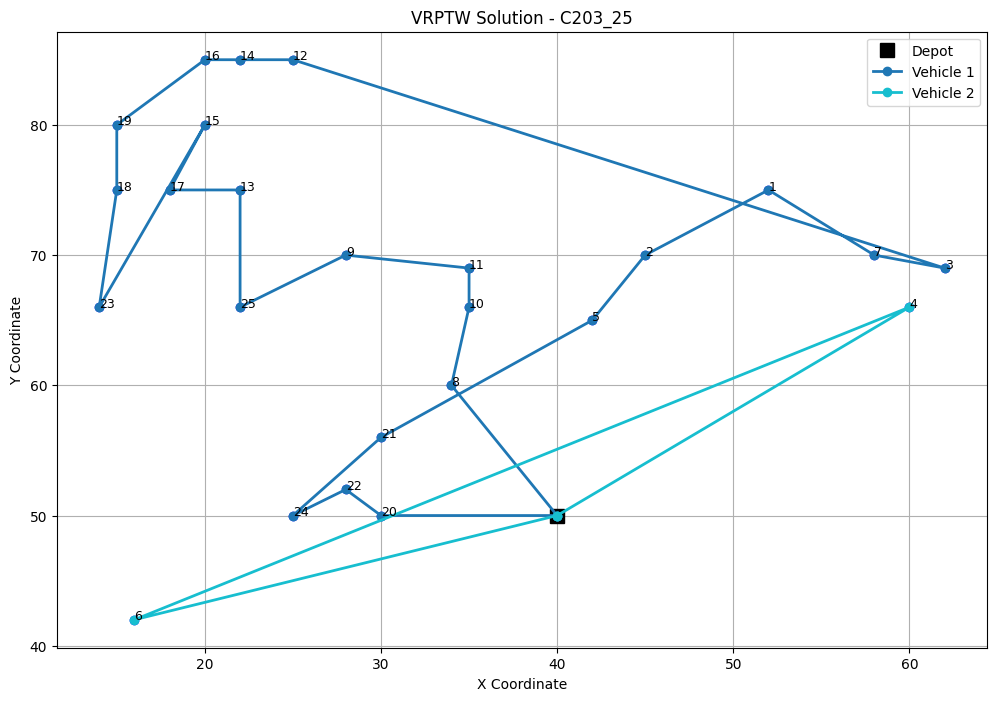


Processing C203_50...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 50 customers (requested: 50)
Successfully loaded C203_50:
  - Number of customers: 50
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=250, E=8
Starting greedy construction for 50 customers...
Vehicle 1: Starting from depot, remaining customers: 50
  Added customer 20, remaining: 49
  Added customer 22, remaining: 48
  Added customer 24, remaining: 47
  Added customer 27, remaining: 46
  Added customer 29, remaining: 45
  Added customer 6, remaining: 44
  Added customer 32, remaining: 43
  Added customer 33, remaining: 42
  Added customer 34, remaining: 41
  Added customer 37, remaining: 40
  Added customer 35, remaining: 39
  Added customer 31, remaining: 38
  Added customer 38, remaining: 37
  Added customer 39, remaining: 36
  Added customer 36, r

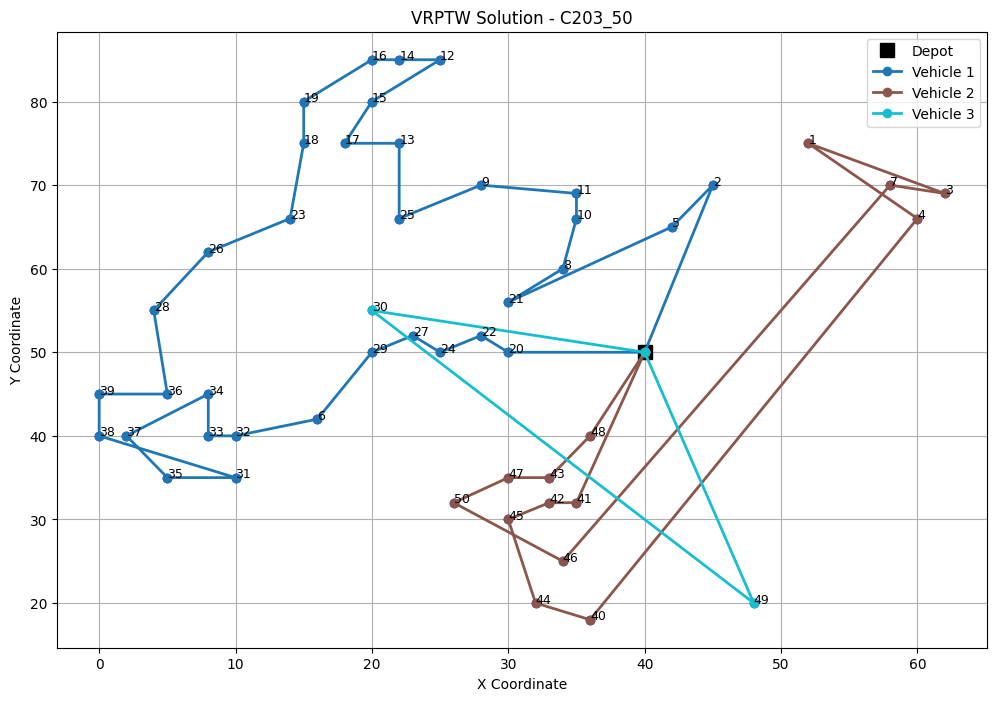


Processing C203_75...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 75 customers (requested: 75)
Successfully loaded C203_75:
  - Number of customers: 75
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=200, E=6
Starting greedy construction for 75 customers...
Vehicle 1: Starting from depot, remaining customers: 75
  Added customer 20, remaining: 74
  Added customer 22, remaining: 73
  Added customer 24, remaining: 72
  Added customer 27, remaining: 71
  Added customer 29, remaining: 70
  Added customer 6, remaining: 69
  Added customer 32, remaining: 68
  Added customer 33, remaining: 67
  Added customer 34, remaining: 66
  Added customer 37, remaining: 65
  Added customer 35, remaining: 64
  Added customer 31, remaining: 63
  Added customer 38, remaining: 62
  Added customer 39, remaining: 61
  Added customer 36, r

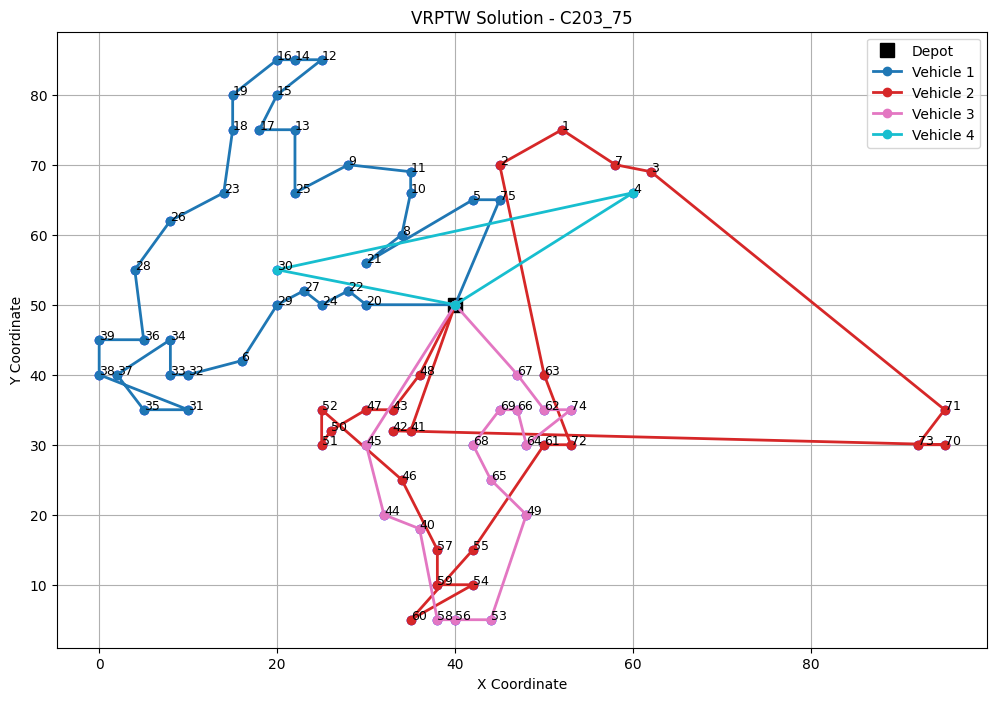


Processing C203_100...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 100 customers (requested: 100)
Successfully loaded C203_100:
  - Number of customers: 100
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=150, E=5
Starting greedy construction for 100 customers...
Vehicle 1: Starting from depot, remaining customers: 100
  Added customer 93, remaining: 99
  Added customer 5, remaining: 98
  Added customer 75, remaining: 97
  Added customer 2, remaining: 96
  Added customer 1, remaining: 95
  Added customer 99, remaining: 94
  Added customer 100, remaining: 93
  Added customer 97, remaining: 92
  Added customer 95, remaining: 91
  Added customer 94, remaining: 90
  Added customer 98, remaining: 89
  Added customer 7, remaining: 88
  Added customer 3, remaining: 87
  Added customer 4, remaining: 86
  Added customer 89

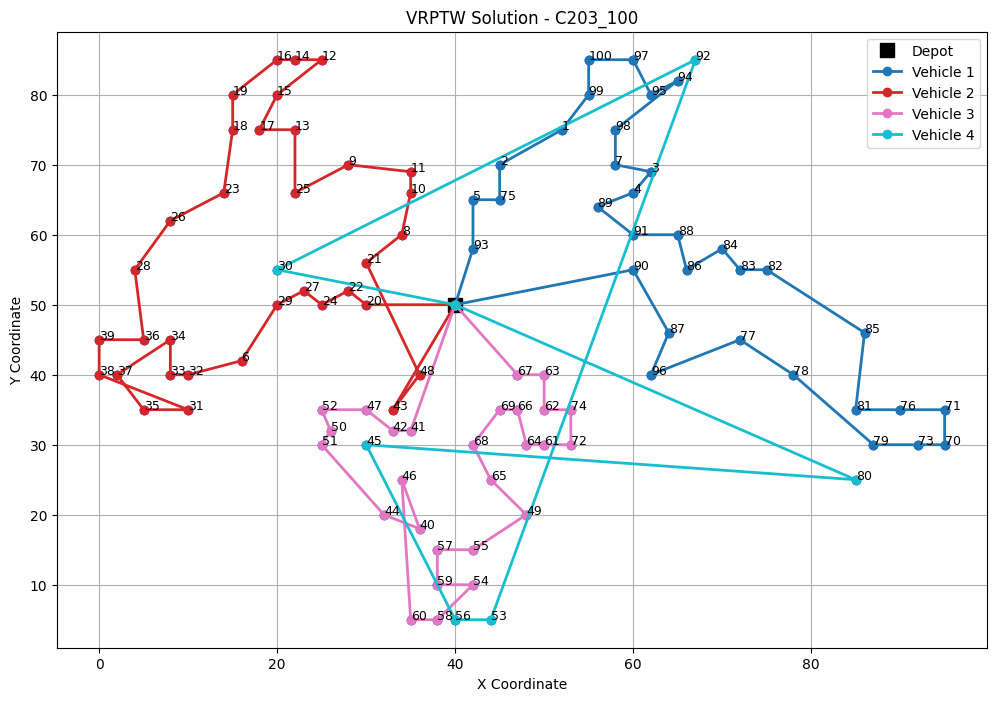


Processing R1_2_3_200...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '50          200'
  Parts: ['50', '200']
  Extracted capacity: 200
Loaded 200 customers (requested: 200)
Successfully loaded R1_2_3_200:
  - Number of customers: 200
  - Vehicle capacity: 200
  - Depot: (70.0, 70.0, 0.0, 634.0)
  - Max vehicles allowed: 50
  - Algorithm parameters: H=100, E=3
Starting greedy construction for 200 customers...
Vehicle 1: Starting from depot, remaining customers: 200
  Added customer 149, remaining: 199
  Added customer 81, remaining: 198
  Added customer 154, remaining: 197
  Added customer 103, remaining: 196
  Added customer 1, remaining: 195
  Added customer 31, remaining: 194
  Added customer 143, remaining: 193
  Added customer 156, remaining: 192
  Added customer 66, remaining: 191
  Added customer 117, remaining: 190
  Added customer 195, remaining: 189
  Added customer 79, remaining: 188
Vehicle 1 route: [0, 149, 81, 154, 103, 1, 31, 143, 156, 66, 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math
from collections import defaultdict
from sklearn.cluster import KMeans

# Hàm đọc dữ liệu từ file Solomon/Gehring-Homberger
def read_vrptw_instance(file_path, max_customers=None):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    node_coords = []
    demands = []
    time_windows = []
    service_times = []
    capacity = 0
    depot = None

    # Phân tích phần header
    i = 0
    while i < len(lines):
        line = lines[i].strip()

        if line == "VEHICLE":
            # Định dạng multi-line VEHICLE
            # Dòng tiếp theo: "NUMBER     CAPACITY"
            # Dòng sau đó: "  25         700"
            if i + 2 < len(lines):
                capacity_line = lines[i + 2].strip()
                parts = capacity_line.split()
                print(f"VEHICLE section found:")
                print(f"  Header line: '{lines[i + 1].strip()}'")
                print(f"  Data line: '{capacity_line}'")
                print(f"  Parts: {parts}")

                if len(parts) >= 2:
                    try:
                        capacity = int(parts[1])  # Capacity là phần tử thứ 2
                        print(f"  Extracted capacity: {capacity}")
                    except ValueError:
                        print(f"  Error: Could not parse capacity from '{parts[1]}'")
                        capacity = 200  # Default
            i += 3  # Skip the VEHICLE section

        elif line.startswith("VEHICLE"):
            # Định dạng single-line VEHICLE (fallback)
            parts = line.split()
            print(f"VEHICLE line: '{line}'")
            print(f"Parts: {parts}")
            print(f"Number of parts: {len(parts)}")

            # Try different common formats for VEHICLE capacity
            if len(parts) >= 6:  # Original format assumption
                capacity = int(parts[5])
            elif len(parts) >= 4:  # Alternative format: VEHICLE NUMBER CAPACITY xxx
                try:
                    capacity = int(parts[3])
                except ValueError:
                    capacity = int(parts[2])
            elif len(parts) >= 3:  # Another format: VEHICLE CAPACITY xxx
                try:
                    capacity = int(parts[2])
                except ValueError:
                    # Look for the first number in the line that could be capacity
                    for part in parts[1:]:
                        try:
                            capacity = int(part)
                            break
                        except ValueError:
                            continue

            print(f"Extracted capacity: {capacity}")
            i += 1

        elif line.startswith("CUSTOMER") or line.startswith("CUST NO."):
            i += 1
            break
        else:
            i += 1

    # Phân tích phần dữ liệu khách hàng
    customer_count = 0
    while i < len(lines):
        line = lines[i].strip()
        if line == "" or line.startswith("CUST"):
            i += 1
            continue

        parts = line.split()
        if len(parts) < 7:
            i += 1
            continue

        try:
            node_id = int(parts[0])
            x = float(parts[1])
            y = float(parts[2])
            demand = float(parts[3])
            ready = float(parts[4])
            due = float(parts[5])
            service = float(parts[6])

            if node_id == 0:  # Depot
                depot = (x, y, ready, due)
            else:
                # Kiểm tra giới hạn số lượng khách hàng
                if max_customers is None or customer_count < max_customers:
                    node_coords.append((x, y))
                    demands.append(demand)
                    time_windows.append((ready, due))
                    service_times.append(service)
                    customer_count += 1
                else:
                    break  # Đã đủ số lượng khách hàng yêu cầu
        except (ValueError, IndexError) as e:
            print(f"Error parsing line: '{line}' - {e}")

        i += 1

    # Fallback capacity if not found
    if capacity == 0:
        capacity = 200  # Default capacity
        print(f"Warning: Could not find vehicle capacity, using default: {capacity}")

    if depot is None:
        print("Error: Could not find depot information")
        return None

    actual_customers = len(demands)
    print(f"Loaded {actual_customers} customers (requested: {max_customers if max_customers else 'all'})")

    return {
        "depot": depot,
        "node_coords": node_coords,
        "demands": demands,
        "time_windows": time_windows,
        "service_times": service_times,
        "capacity": capacity,
        "num_customers": actual_customers
    }

# Hàm tính khoảng cách Euclid
def euclidean_distance(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

# Thuật toán Quy hoạch động giới hạn cho VRPTW
def vrptw_dp(data, H=1000, E=10):
    depot = data["depot"]
    coords = data["node_coords"]
    demands = data["demands"]
    time_windows = data["time_windows"]
    service_times = data["service_times"]
    capacity = data["capacity"]
    n = data["num_customers"]

    # Tính ma trận khoảng cách
    dist_matrix = np.zeros((n+1, n+1))
    for i in range(n+1):
        for j in range(n+1):
            p1 = depot[:2] if i == 0 else coords[i-1]
            p2 = depot[:2] if j == 0 else coords[j-1]
            dist_matrix[i][j] = euclidean_distance(p1, p2)

    # Khởi tạo DP state: (thời gian hiện tại, dung lượng còn lại, vị trí hiện tại)
    # Sử dụng dictionary để lưu trữ cost và parent state
    states = defaultdict(lambda: float('inf'))
    states[(0, capacity, 0)] = 0  # (time, capacity, node)
    parent = {}

    # Các tham số giới hạn
    max_vehicles = 25
    vehicle_count = 1

    # Biến lưu trữ lộ trình
    routes = []

    while vehicle_count <= max_vehicles:
        new_states = defaultdict(lambda: float('inf'))
        state_queue = []

        for state, cost in states.items():
            time_val, cap_val, node = state
            state_queue.append((cost, state))

        # Sắp xếp và chọn H trạng thái tốt nhất
        state_queue.sort(key=lambda x: x[0])
        selected_states = state_queue[:H]

        for cost, state in selected_states:
            time_val, cap_val, node = state

            # Tìm E khách hàng gần nhất chưa được ghé thăm
            neighbors = []
            for next_node in range(1, n+1):
                if next_node == node:
                    continue

                # Kiểm tra ràng buộc thời gian và dung lượng
                travel_time = dist_matrix[node][next_node]
                arrival_time = time_val + travel_time
                ready, due = time_windows[next_node-1]
                service_time = service_times[next_node-1]

                if arrival_time > due or cap_val < demands[next_node-1]:
                    continue

                start_time = max(arrival_time, ready)
                new_time = start_time + service_time
                new_cap = cap_val - demands[next_node-1]
                neighbors.append((next_node, new_time, new_cap, travel_time))

            # Sắp xếp hàng xóm theo khoảng cách
            neighbors.sort(key=lambda x: x[3])

            # Chỉ xem xét E hàng xóm gần nhất
            for next_node, new_time, new_cap, _ in neighbors[:E]:
                new_state = (new_time, new_cap, next_node)
                new_cost = cost + dist_matrix[node][next_node]

                if new_cost < new_states[new_state]:
                    new_states[new_state] = new_cost
                    parent[new_state] = (state, next_node)

        # Kiểm tra nếu không còn trạng thái mới
        if not new_states:
            break

        states = new_states
        vehicle_count += 1

    # Tái tạo lộ trình từ parent dictionary
    for state in states:
        route = []
        current_state = state
        while current_state in parent:
            prev_state, node = parent[current_state]
            route.append(node)
            current_state = prev_state
        if route:
            route.reverse()
            routes.append([0] + route + [0])

    return routes

# Hàm visual hoá kết quả
def visualize_routes(data, routes, title="VRPTW Solution"):
    plt.figure(figsize=(12, 8))

    # Vẽ depot
    depot = data["depot"]
    plt.plot(depot[0], depot[1], 'ks', markersize=10, label='Depot')

    # Vẽ các khách hàng
    for i, coord in enumerate(data["node_coords"]):
        plt.plot(coord[0], coord[1], 'bo')
        plt.text(coord[0], coord[1], f"{i+1}", fontsize=9)

    # Vẽ các tuyến đường
    colors = plt.cm.tab10(np.linspace(0, 1, len(routes)))
    for i, route in enumerate(routes):
        x = []
        y = []
        for node in route:
            if node == 0:
                x.append(depot[0])
                y.append(depot[1])
            else:
                x.append(data["node_coords"][node-1][0])
                y.append(data["node_coords"][node-1][1])

        plt.plot(x, y, 'o-', color=colors[i], linewidth=2, label=f'Vehicle {i+1}')

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Thuật toán VRPTW đảm bảo đi qua tất cả khách hàng
def vrptw_dp_complete(data, max_vehicles=25, H=200, E=8):
    depot = data["depot"]
    coords = data["node_coords"]
    demands = data["demands"]
    time_windows = data["time_windows"]
    service_times = data["service_times"]
    capacity = data["capacity"]
    n = data["num_customers"]

    # Tính ma trận khoảng cách
    dist_matrix = np.zeros((n+1, n+1))
    for i in range(n+1):
        for j in range(n+1):
            p1 = depot[:2] if i == 0 else coords[i-1]
            p2 = depot[:2] if j == 0 else coords[j-1]
            dist_matrix[i][j] = euclidean_distance(p1, p2)

    # Greedy Construction để đảm bảo tất cả khách hàng được ghé thăm
    unvisited = set(range(1, n+1))  # Tất cả khách hàng chưa ghé thăm
    routes = []

    print(f"Starting greedy construction for {n} customers...")

    vehicle_count = 0
    while unvisited and vehicle_count < max_vehicles:
        route = [0]  # Bắt đầu từ depot
        current_time = depot[2]  # ready time của depot
        current_capacity = capacity
        current_node = 0

        print(f"Vehicle {vehicle_count + 1}: Starting from depot, remaining customers: {len(unvisited)}")

        # Xây dựng route cho vehicle hiện tại
        while unvisited:
            best_customer = None
            best_cost = float('inf')
            best_arrival_time = 0

            # Tìm khách hàng tốt nhất có thể ghé thăm
            for customer in unvisited:
                travel_time = dist_matrix[current_node][customer]
                arrival_time = current_time + travel_time
                ready, due = time_windows[customer-1]
                demand = demands[customer-1]
                service_time = service_times[customer-1]

                # Kiểm tra ràng buộc
                if (arrival_time <= due and
                    current_capacity >= demand and
                    current_capacity >= demand):

                    # Tính chi phí (khoảng cách + penalty cho việc đợi)
                    wait_time = max(0, ready - arrival_time)
                    cost = travel_time + 0.1 * wait_time

                    if cost < best_cost:
                        best_cost = cost
                        best_customer = customer
                        best_arrival_time = max(arrival_time, ready)

            # Nếu không tìm được khách hàng nào, kết thúc route này
            if best_customer is None:
                break

            # Thêm khách hàng vào route
            route.append(best_customer)
            unvisited.remove(best_customer)
            current_node = best_customer
            current_time = best_arrival_time + service_times[best_customer-1]
            current_capacity -= demands[best_customer-1]

            print(f"  Added customer {best_customer}, remaining: {len(unvisited)}")

        # Quay về depot
        route.append(0)
        routes.append(route)
        vehicle_count += 1

        print(f"Vehicle {vehicle_count} route: {route}, customers served: {len(route)-2}")

    # Nếu còn khách hàng chưa ghé thăm và còn xe
    if unvisited and vehicle_count < max_vehicles:
        print(f"Warning: {len(unvisited)} customers still unvisited: {sorted(unvisited)}")

        # Cố gắng thêm các khách hàng còn lại vào routes hiện tại
        for customer in list(unvisited):
            best_route_idx = -1
            best_position = -1
            best_cost_increase = float('inf')

            # Thử chèn vào các route hiện tại
            for route_idx, route in enumerate(routes):
                for pos in range(1, len(route)-1):  # Không chèn ở depot
                    # Kiểm tra xem có thể chèn customer vào vị trí pos không
                    if can_insert_customer(route, pos, customer, data, dist_matrix):
                        cost_increase = calculate_insertion_cost(route, pos, customer, dist_matrix)
                        if cost_increase < best_cost_increase:
                            best_cost_increase = cost_increase
                            best_route_idx = route_idx
                            best_position = pos

            if best_route_idx != -1:
                routes[best_route_idx].insert(best_position, customer)
                unvisited.remove(customer)
                print(f"Inserted customer {customer} into route {best_route_idx+1}")

    if unvisited:
        print(f"ERROR: Could not visit all customers. Unvisited: {sorted(unvisited)}")
        print(f"Used {len(routes)} out of {max_vehicles} vehicles")
    else:
        print(f"SUCCESS: All customers visited using {len(routes)} vehicles")

    return routes

# Hàm kiểm tra có thể chèn khách hàng vào route không
def can_insert_customer(route, position, customer, data, dist_matrix):
    if position <= 0 or position >= len(route):
        return False

    # Tạo route tạm thời với customer được chèn vào
    temp_route = route[:]
    temp_route.insert(position, customer)

    # Kiểm tra ràng buộc capacity
    total_demand = 0
    for node in temp_route:
        if node != 0:  # Không tính depot
            total_demand += data["demands"][node-1]

    if total_demand > data["capacity"]:
        return False

    # Kiểm tra ràng buộc thời gian
    current_time = data["depot"][2]  # depot ready time

    for i in range(1, len(temp_route)-1):  # Bỏ qua depot đầu và cuối
        prev_node = temp_route[i-1]
        curr_node = temp_route[i]

        travel_time = dist_matrix[prev_node][curr_node]
        current_time += travel_time

        ready, due = data["time_windows"][curr_node-1]

        if current_time > due:
            return False

        current_time = max(current_time, ready) + data["service_times"][curr_node-1]

    return True

# Hàm tính chi phí chèn khách hàng
def calculate_insertion_cost(route, position, customer, dist_matrix):
    if position <= 0 or position >= len(route):
        return float('inf')

    prev_node = route[position-1]
    next_node = route[position]

    # Chi phí cũ: prev -> next
    old_cost = dist_matrix[prev_node][next_node]

    # Chi phí mới: prev -> customer -> next
    new_cost = dist_matrix[prev_node][customer] + dist_matrix[customer][next_node]

    return new_cost - old_cost

# Hàm main xử lý tất cả bộ dữ liệu
def main():
    # Test cases cho cả hai file dữ liệu
    # Chú ý: Điều chỉnh đường dẫn file cho phù hợp với môi trường của bạn
    # - Colab: "/content/filename.txt"
    # - Windows: r"C:\path\to\file.txt"

    test_cases = {
        # C203 dataset - 25 vehicles, capacity 700 (4 trường hợp)
        "C203_25": {"file": "/content/c203.txt", "max_customers": 25, "max_vehicles": 25},
        "C203_50": {"file": "/content/c203.txt", "max_customers": 50, "max_vehicles": 25},
        "C203_75": {"file": "/content/c203.txt", "max_customers": 75, "max_vehicles": 25},
        "C203_100": {"file": "/content/c203.txt", "max_customers": 100, "max_vehicles": 25},

        # R1_2_3 (GH200) dataset - 50 vehicles, capacity 200 (chỉ test 200 khách)
        "R1_2_3_200": {"file": r"/content/R1_2_3.TXT", "max_customers": 200, "max_vehicles": 50}
    }

    results = {}

    for name, config in test_cases.items():
        print(f"\n{'='*60}")
        print(f"Processing {name}...")
        print(f"{'='*60}")

        try:
            start_time = time.time()

            # Đọc dữ liệu với giới hạn số lượng khách hàng
            data = read_vrptw_instance(config["file"], config["max_customers"])

            if data is None:
                print(f"Error: Could not read data from {config['file']}")
                continue

            max_vehicles = config["max_vehicles"]

            print(f"Successfully loaded {name}:")
            print(f"  - Number of customers: {data['num_customers']}")
            print(f"  - Vehicle capacity: {data['capacity']}")
            print(f"  - Depot: {data['depot']}")
            print(f"  - Max vehicles allowed: {max_vehicles}")

            # Điều chỉnh tham số theo kích thước bài toán
            if data['num_customers'] <= 25:
                H, E = 300, 10  # Tham số cao cho bài toán nhỏ
            elif data['num_customers'] <= 50:
                H, E = 250, 8   # Tham số trung bình
            elif data['num_customers'] <= 75:
                H, E = 200, 6   # Tham số thấp hơn
            elif data['num_customers'] <= 100:
                H, E = 150, 5   # Tham số thấp cho bài toán lớn
            else:
                H, E = 100, 3   # Tham số rất thấp cho bài toán rất lớn (200 customers)

            print(f"  - Algorithm parameters: H={H}, E={E}")

            # Giải bằng thuật toán đảm bảo đi qua tất cả khách hàng
            routes = vrptw_dp_complete(data, max_vehicles=max_vehicles, H=H, E=E)

            # Tính thời gian chạy
            elapsed = time.time() - start_time

            # Kiểm tra coverage
            visited_customers = set()
            total_distance = 0

            for route in routes:
                for j in range(len(route)-1):
                    node1 = route[j]
                    node2 = route[j+1]

                    # Tính khoảng cách
                    if node1 == 0:
                        p1 = data["depot"][:2]
                    else:
                        p1 = data["node_coords"][node1-1]

                    if node2 == 0:
                        p2 = data["depot"][:2]
                    else:
                        p2 = data["node_coords"][node2-1]

                    total_distance += euclidean_distance(p1, p2)

                for node in route:
                    if node != 0:  # Không tính depot
                        visited_customers.add(node)

            coverage = len(visited_customers)
            total_customers = data['num_customers']

            # Lưu kết quả
            results[name] = {
                "routes": routes,
                "time": elapsed,
                "num_vehicles": len(routes),
                "max_vehicles": max_vehicles,
                "coverage": coverage,
                "total_customers": total_customers,
                "total_distance": round(total_distance, 2)
            }

            # In kết quả chi tiết
            print(f"\nResults for {name}:")
            print(f"  - Solved in: {elapsed:.2f} seconds")
            print(f"  - Vehicles used: {len(routes)}/{max_vehicles}")
            print(f"  - Customers served: {coverage}/{total_customers} ({100*coverage/total_customers:.1f}%)")
            print(f"  - Total distance: {total_distance:.2f}")

            if coverage < total_customers:
                unvisited = set(range(1, total_customers + 1)) - visited_customers
                print(f"  - Unvisited customers: {sorted(unvisited)}")

            print(f"\nRoute details:")
            for i, route in enumerate(routes):
                route_distance = 0
                route_demand = 0

                for j in range(len(route)-1):
                    node1 = route[j]
                    node2 = route[j+1]

                    if node1 == 0:
                        p1 = data["depot"][:2]
                    else:
                        p1 = data["node_coords"][node1-1]
                        route_demand += data["demands"][node1-1]

                    if node2 == 0:
                        p2 = data["depot"][:2]
                    else:
                        p2 = data["node_coords"][node2-1]

                    route_distance += euclidean_distance(p1, p2)

                print(f"  Vehicle {i+1}: {route}")
                print(f"    Distance: {route_distance:.2f}, Demand: {route_demand}/{data['capacity']}")

            # Visualization (bỏ qua cho bài toán quá lớn để tránh quá tải)
            if data['num_customers'] <= 100:
                print(f"\n  - Generating visualization for {name}...")
                visualize_routes(data, routes, title=f"VRPTW Solution - {name}")
            else:
                print(f"\n  - Skipping visualization for {name} (too many customers: {data['num_customers']})")
                print(f"    You can enable visualization by removing the condition if needed.")

        except FileNotFoundError:
            print(f"Error: File {config['file']} not found")
            continue
        except Exception as e:
            print(f"Error processing {name}: {e}")
            import traceback
            traceback.print_exc()
            continue

    # Tổng kết tất cả các trường hợp
    print(f"\n{'='*100}")
    print("SUMMARY OF ALL TEST CASES:")
    print(f"{'='*100}")
    print(f"{'Case':<15} {'Time(s)':<8} {'Vehicles':<12} {'Coverage':<12} {'Distance':<10} {'Dataset':<10}")
    print(f"{'-'*100}")

    for name, res in results.items():
        coverage_pct = f"{res['coverage']}/{res['total_customers']}"
        vehicles_pct = f"{res['num_vehicles']}/{res['max_vehicles']}"
        dataset = "C203" if "C203" in name else "R1_2_3"
        print(f"{name:<15} {res['time']:<8.2f} {vehicles_pct:<12} {coverage_pct:<12} {res['total_distance']:<10.2f} {dataset:<10}")

    print(f"{'-'*100}")

    return results

if __name__ == "__main__":
    main()


🚀 VRPTW Solver - COMPLETE COVERAGE MODE
⚠️  WARNING: Thuật toán được tối ưu để đảm bảo 100% coverage
   - Thời gian chạy có thể rất lâu (từ vài phút đến vài giờ)
   - Ưu tiên tìm solution hoàn chỉnh hơn là tốc độ
   - Có thể chạy đến 2 giờ cho mỗi test case nếu cần
------------------------------------------------------------

Processing C203_25...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 25 customers (requested: 25)
Successfully loaded C203_25:
  - Number of customers: 25
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=500, E=15
  - Time limit: 30 minutes
  - Priority: Complete coverage (100% customers)
Starting Enhanced Dynamic Programming for 25 customers...
DP Parameters: H=500 (max states), E=15 (max neighbors), Time limit: 30min
Multi-start configuration: 5 restarts for 25 customers
Restart 0, Iter 1: 1 sta

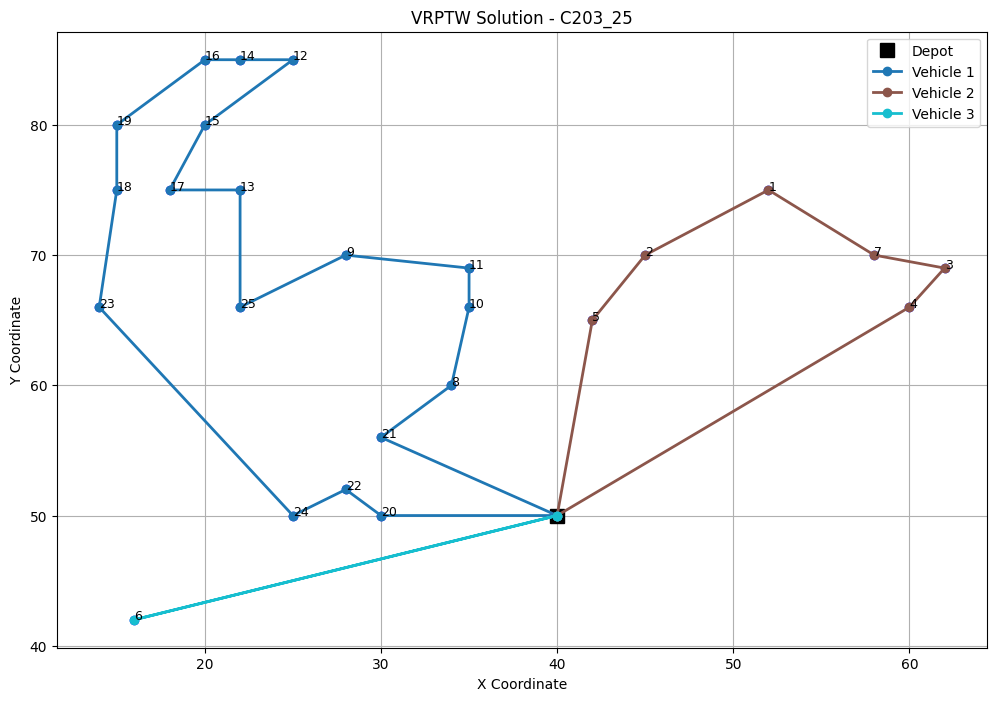


Processing C203_50...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 50 customers (requested: 50)
Successfully loaded C203_50:
  - Number of customers: 50
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=400, E=12
  - Time limit: 40 minutes
  - Priority: Complete coverage (100% customers)
Starting Enhanced Dynamic Programming for 50 customers...
DP Parameters: H=400 (max states), E=12 (max neighbors), Time limit: 40min
Multi-start configuration: 5 restarts for 50 customers
Restart 0, Iter 1: 1 states, Max coverage: 0/50, Time: 0.0s
Restart 0, Iter 2: 12 states, Max coverage: 1/50, Time: 0.0s
Restart 0, Iter 3: 156 states, Max coverage: 2/50, Time: 0.0s
Restart 0, Iter 4: 1890 states, Max coverage: 3/50, Time: 0.0s
Restart 0, Iter 5: 3476 states, Max coverage: 4/50, Time: 0.0s
Restart 0, Iter 6: 3386 states, Max covera

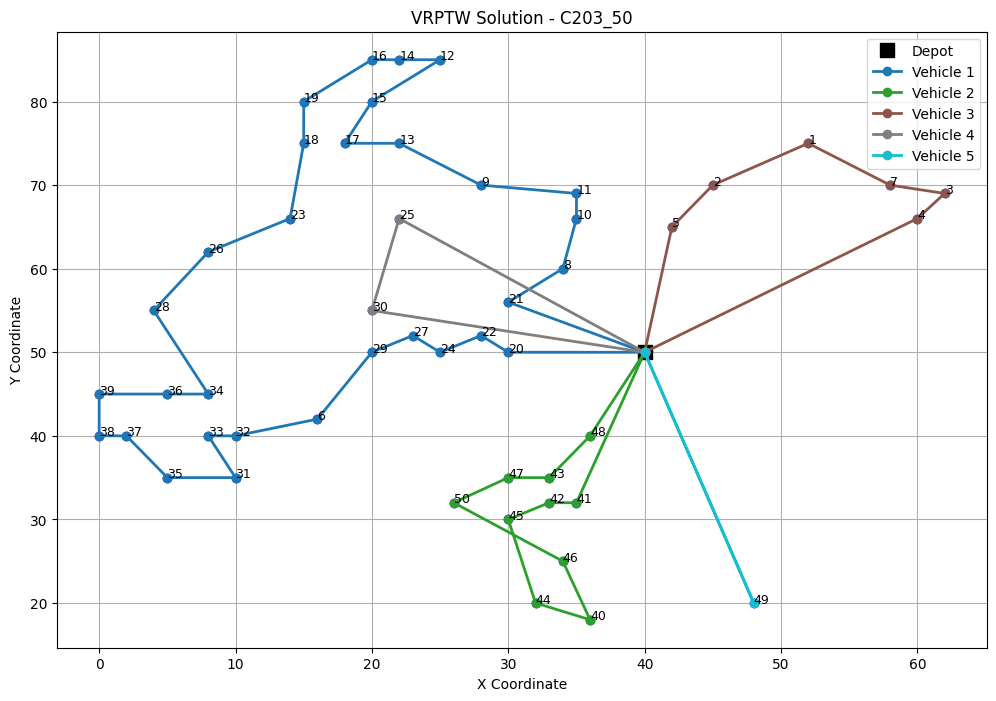


Processing C203_75...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 75 customers (requested: 75)
Successfully loaded C203_75:
  - Number of customers: 75
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=300, E=10
  - Time limit: 60 minutes
  - Priority: Complete coverage (100% customers)
Starting Enhanced Dynamic Programming for 75 customers...
DP Parameters: H=300 (max states), E=10 (max neighbors), Time limit: 60min
Multi-start configuration: 5 restarts for 75 customers
Restart 0, Iter 1: 1 states, Max coverage: 0/75, Time: 0.0s
Restart 0, Iter 2: 10 states, Max coverage: 1/75, Time: 0.0s
Restart 0, Iter 3: 110 states, Max coverage: 2/75, Time: 0.0s
Restart 0, Iter 4: 1127 states, Max coverage: 3/75, Time: 0.0s
Restart 0, Iter 5: 2207 states, Max coverage: 4/75, Time: 0.1s
Restart 0, Iter 6: 2220 states, Max covera

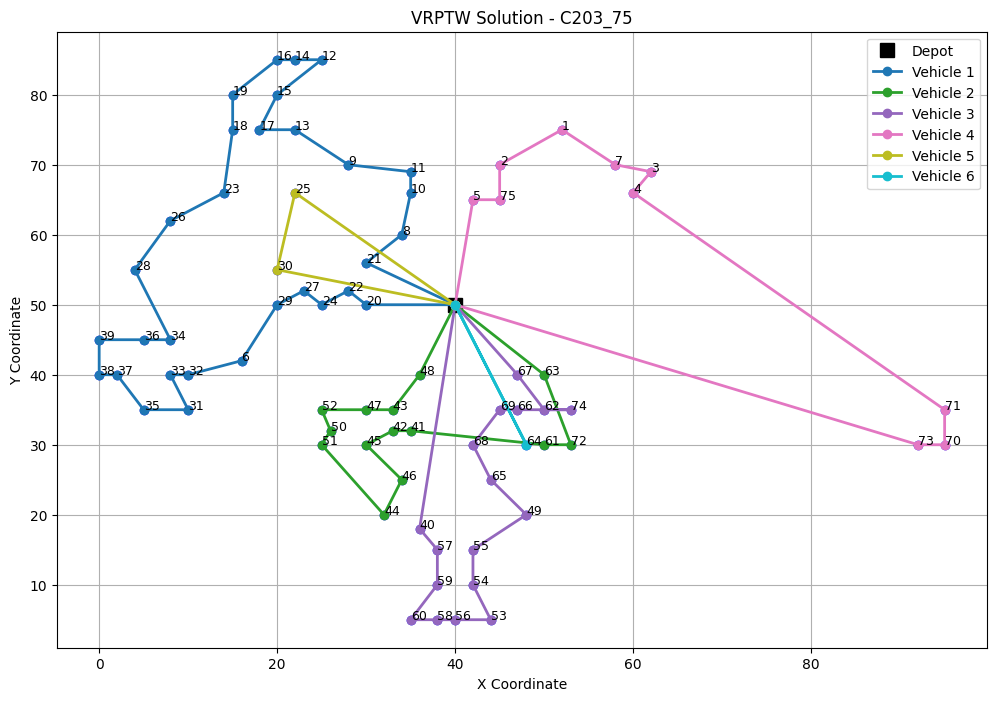


Processing C203_100...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 100 customers (requested: 100)
Successfully loaded C203_100:
  - Number of customers: 100
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=250, E=8
  - Time limit: 80 minutes
  - Priority: Complete coverage (100% customers)
Starting Enhanced Dynamic Programming for 100 customers...
DP Parameters: H=250 (max states), E=8 (max neighbors), Time limit: 80min
Multi-start configuration: 5 restarts for 100 customers
Restart 0, Iter 1: 1 states, Max coverage: 0/100, Time: 0.0s
Restart 0, Iter 2: 8 states, Max coverage: 1/100, Time: 0.0s
Restart 0, Iter 3: 72 states, Max coverage: 2/100, Time: 0.0s
Restart 0, Iter 4: 600 states, Max coverage: 3/100, Time: 0.0s
Restart 0, Iter 5: 1511 states, Max coverage: 4/100, Time: 0.0s
Restart 0, Iter 6: 1518 states, Max

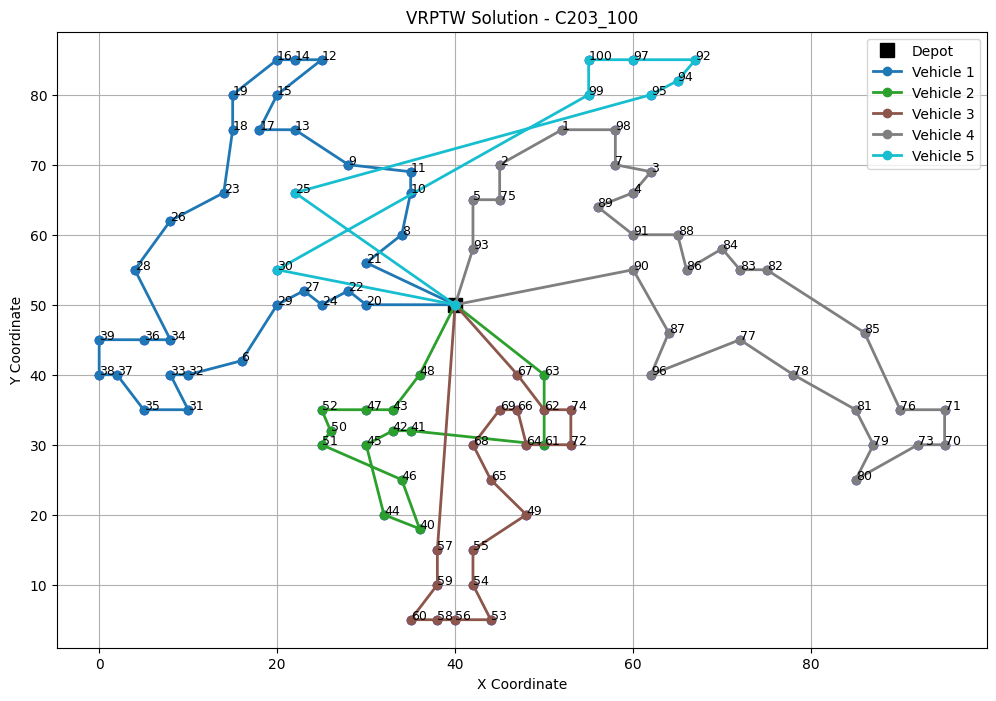


Processing R1_2_3_200...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '50          200'
  Parts: ['50', '200']
  Extracted capacity: 200
Loaded 200 customers (requested: 200)
Successfully loaded R1_2_3_200:
  - Number of customers: 200
  - Vehicle capacity: 200
  - Depot: (70.0, 70.0, 0.0, 634.0)
  - Max vehicles allowed: 50
  - Algorithm parameters: H=400, E=10
  - Time limit: 120 minutes
  - Priority: Complete coverage (100% customers)
Starting Enhanced Dynamic Programming for 200 customers...
DP Parameters: H=400 (max states), E=10 (max neighbors), Time limit: 120min
Multi-start configuration: 10 restarts for 200 customers
Restart 0, Iter 1: 1 states, Max coverage: 0/200, Time: 0.0s
Restart 0, Iter 2: 10 states, Max coverage: 1/200, Time: 0.0s
Restart 0, Iter 3: 110 states, Max coverage: 2/200, Time: 0.0s
Restart 0, Iter 4: 1140 states, Max coverage: 3/200, Time: 0.1s
  Memory optimization: Reducing 3121 states to 400
Restart 0, Iter 5: 400 states, Max c

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# Hàm đọc dữ liệu từ file Solomon/Gehring-Homberger
def read_vrptw_instance(file_path, max_customers=None):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    node_coords = []
    demands = []
    time_windows = []
    service_times = []
    capacity = 0
    depot = None

    # Phân tích phần header
    i = 0
    while i < len(lines):
        line = lines[i].strip()

        if line == "VEHICLE":
            # Định dạng multi-line VEHICLE
            # Dòng tiếp theo: "NUMBER     CAPACITY"
            # Dòng sau đó: "  25         700"
            if i + 2 < len(lines):
                capacity_line = lines[i + 2].strip()
                parts = capacity_line.split()
                print(f"VEHICLE section found:")
                print(f"  Header line: '{lines[i + 1].strip()}'")
                print(f"  Data line: '{capacity_line}'")
                print(f"  Parts: {parts}")

                if len(parts) >= 2:
                    try:
                        capacity = int(parts[1])  # Capacity là phần tử thứ 2
                        print(f"  Extracted capacity: {capacity}")
                    except ValueError:
                        print(f"  Error: Could not parse capacity from '{parts[1]}'")
                        capacity = 200  # Default
            i += 3  # Skip the VEHICLE section

        elif line.startswith("VEHICLE"):
            # Định dạng single-line VEHICLE (fallback)
            parts = line.split()
            print(f"VEHICLE line: '{line}'")
            print(f"Parts: {parts}")
            print(f"Number of parts: {len(parts)}")

            # Try different common formats for VEHICLE capacity
            if len(parts) >= 6:  # Original format assumption
                capacity = int(parts[5])
            elif len(parts) >= 4:  # Alternative format: VEHICLE NUMBER CAPACITY xxx
                try:
                    capacity = int(parts[3])
                except ValueError:
                    capacity = int(parts[2])
            elif len(parts) >= 3:  # Another format: VEHICLE CAPACITY xxx
                try:
                    capacity = int(parts[2])
                except ValueError:
                    # Look for the first number in the line that could be capacity
                    for part in parts[1:]:
                        try:
                            capacity = int(part)
                            break
                        except ValueError:
                            continue

            print(f"Extracted capacity: {capacity}")
            i += 1

        elif line.startswith("CUSTOMER") or line.startswith("CUST NO."):
            i += 1
            break
        else:
            i += 1

    # Phân tích phần dữ liệu khách hàng
    customer_count = 0
    while i < len(lines):
        line = lines[i].strip()
        if line == "" or line.startswith("CUST"):
            i += 1
            continue

        parts = line.split()
        if len(parts) < 7:
            i += 1
            continue

        try:
            node_id = int(parts[0])
            x = float(parts[1])
            y = float(parts[2])
            demand = float(parts[3])
            ready = float(parts[4])
            due = float(parts[5])
            service = float(parts[6])

            if node_id == 0:  # Depot
                depot = (x, y, ready, due)
            else:
                # Kiểm tra giới hạn số lượng khách hàng
                if max_customers is None or customer_count < max_customers:
                    node_coords.append((x, y))
                    demands.append(demand)
                    time_windows.append((ready, due))
                    service_times.append(service)
                    customer_count += 1
                else:
                    break  # Đã đủ số lượng khách hàng yêu cầu
        except (ValueError, IndexError) as e:
            print(f"Error parsing line: '{line}' - {e}")

        i += 1

    # Fallback capacity if not found
    if capacity == 0:
        capacity = 200  # Default capacity
        print(f"Warning: Could not find vehicle capacity, using default: {capacity}")

    if depot is None:
        print("Error: Could not find depot information")
        return None

    actual_customers = len(demands)
    print(f"Loaded {actual_customers} customers (requested: {max_customers if max_customers else 'all'})")

    return {
        "depot": depot,
        "node_coords": node_coords,
        "demands": demands,
        "time_windows": time_windows,
        "service_times": service_times,
        "capacity": capacity,
        "num_customers": actual_customers
    }

# Hàm tính khoảng cách Euclid
def euclidean_distance(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

# Thuật toán Quy hoạch động giới hạn cho VRPTW với forced complete coverage
def vrptw_dp(data, H=1000, E=10, time_limit=3600):
    depot = data["depot"]
    coords = data["node_coords"]
    demands = data["demands"]
    time_windows = data["time_windows"]
    service_times = data["service_times"]
    capacity = data["capacity"]
    n = data["num_customers"]

    start_time = time.time()
    print(f"Starting Enhanced Dynamic Programming for {n} customers...")
    print(f"DP Parameters: H={H} (max states), E={E} (max neighbors), Time limit: {time_limit//60}min")

    # Tính ma trận khoảng cách
    dist_matrix = np.zeros((n+1, n+1))
    for i in range(n+1):
        for j in range(n+1):
            p1 = depot[:2] if i == 0 else coords[i-1]
            p2 = depot[:2] if j == 0 else coords[j-1]
            dist_matrix[i][j] = euclidean_distance(p1, p2)

    # Tối ưu: Tính trước nearest neighbors cho mỗi node
    nearest_neighbors = {}
    for i in range(n+1):
        neighbors = []
        for j in range(n+1):
            if i != j:
                neighbors.append((j, dist_matrix[i][j]))
        neighbors.sort(key=lambda x: x[1])
        nearest_neighbors[i] = neighbors

    best_complete_solution = None
    best_complete_cost = float('inf')
    best_coverage = 0
    best_partial_solution = None

    # Multi-start approach với forced diversification - đặc biệt tối ưu cho 200 customers
    restart_count = 0
    max_restarts = 10 if n >= 200 else 5  # Tăng restarts cho bài toán lớn

    print(f"Multi-start configuration: {max_restarts} restarts for {n} customers")

    while restart_count <= max_restarts:
        if restart_count > 0:
            print(f"\n🔄 Restart #{restart_count} - Forcing exploration of different customer sets...")

        # DP state: (visited_set, current_time, current_capacity, current_node)
        states = {}
        states[frozenset(), 0, capacity, 0] = {'cost': 0, 'parent': None, 'action': None}

        # Enhanced customer diversification cho bài toán lớn
        if restart_count > 0:
            priority_customers = list(range(1, n+1))
            np.random.seed(restart_count * 42)  # Deterministic randomness
            np.random.shuffle(priority_customers)

            if n >= 200:
                # Cho 200 customers: chia thành nhiều nhóm nhỏ hơn với overlap
                customers_per_restart = n // (max_restarts - 2)  # Overlap để đảm bảo coverage
                start_idx = max(0, (restart_count - 1) * customers_per_restart - 10)
                end_idx = min((restart_count) * customers_per_restart + 10, n)
            else:
                # Cho ít hơn 200 customers: logic cũ
                customers_per_restart = max(1, n // max_restarts)
                start_idx = (restart_count - 1) * customers_per_restart
                end_idx = min(restart_count * customers_per_restart, n)

            priority_set = set(priority_customers[start_idx:end_idx])
            print(f"   Priority customers for restart {restart_count}: {len(priority_set)} customers from {min(priority_set) if priority_set else 'none'} to {max(priority_set) if priority_set else 'none'}")
        else:
            priority_set = set()

        iteration = 0
        max_iterations = 300 if n >= 200 else 200  # Tăng iterations cho bài toán lớn

        while states and iteration < max_iterations:
            iteration += 1
            elapsed = time.time() - start_time

            if elapsed > time_limit:
                print(f"Time limit exceeded ({elapsed:.1f}s).")
                break

            # Tính max coverage hiện tại
            current_max_coverage = max([len(s[0]) for s in states.keys()]) if states else 0

            print(f"Restart {restart_count}, Iter {iteration}: {len(states)} states, Max coverage: {current_max_coverage}/{n}, Time: {elapsed:.1f}s")

            new_states = {}

            # Nhóm states theo coverage level để đảm bảo diversity
            coverage_groups = {}
            for state_key, state_value in states.items():
                visited_set, time_val, cap_val, node = state_key
                coverage = len(visited_set)
                if coverage not in coverage_groups:
                    coverage_groups[coverage] = []
                coverage_groups[coverage].append((state_key, state_value))

            # Xử lý từng nhóm coverage
            total_states_processed = 0
            for coverage_level in sorted(coverage_groups.keys(), reverse=True):
                group_states = coverage_groups[coverage_level]

                # Ưu tiên states có coverage cao hơn với allocation linh hoạt
                if coverage_level == max(coverage_groups.keys()):
                    # Coverage cao nhất gets 50% of H
                    states_to_process = min(H // 2, len(group_states))
                else:
                    # Các coverage khác chia đều phần còn lại
                    remaining_groups = len(coverage_groups) - 1
                    if remaining_groups > 0:
                        states_to_process = min((H // 2) // remaining_groups, len(group_states))
                    else:
                        states_to_process = min(H // 4, len(group_states))

                # Đảm bảo ít nhất process một số states tối thiểu
                states_to_process = max(states_to_process, min(5, len(group_states)))

                # Giới hạn tổng số states processed
                if total_states_processed + states_to_process > H:
                    states_to_process = max(1, H - total_states_processed)

                # Sắp xếp theo cost trong nhóm
                group_states.sort(key=lambda x: x[1]['cost'])
                selected_group_states = group_states[:states_to_process]
                total_states_processed += len(selected_group_states)

                for state_key, state_value in selected_group_states:
                    visited_set, time_val, cap_val, node = state_key
                    cost = state_value['cost']

                    # Kiểm tra nếu đã ghé thăm tất cả khách hàng
                    if len(visited_set) == n:
                        return_cost = cost + dist_matrix[node][0]
                        if return_cost < best_complete_cost:
                            best_complete_cost = return_cost
                            best_complete_solution = (state_key, state_value)
                            print(f"  🎉 Found COMPLETE solution: cost={return_cost:.2f}, coverage=100%")
                        continue

                    # Lưu best partial solution
                    if len(visited_set) > best_coverage:
                        best_coverage = len(visited_set)
                        best_partial_solution = (state_key, state_value)

                    # Tìm customers chưa được ghé thăm
                    unvisited = set(range(1, n+1)) - visited_set

                    # Forced exploration: Đảm bảo có ít nhất một expansion cho mỗi unvisited customer
                    if restart_count > 0 and len(unvisited) > 0:
                        # Ưu tiên priority customers trong restart này
                        priority_unvisited = unvisited & priority_set
                        if priority_unvisited:
                            unvisited = list(priority_unvisited) + list(unvisited - priority_unvisited)
                        else:
                            unvisited = list(unvisited)
                    else:
                        unvisited = list(unvisited)

                    # Neighbor selection với enhanced diversity cho bài toán lớn
                    neighbors = []
                    checked_count = 0

                    # Tăng số neighbors checked cho bài toán lớn
                    if n >= 200:
                        max_check = min(len(unvisited), E * 5)  # Tăng mạnh cho 200 customers
                        urgency_weight = 50  # Tăng trọng số urgency
                        coverage_weight = 200  # Tăng trọng số coverage bonus
                    elif n >= 100:
                        max_check = min(len(unvisited), E * 4)
                        urgency_weight = 30
                        coverage_weight = 150
                    else:
                        max_check = min(len(unvisited), E * 3)
                        urgency_weight = 20
                        coverage_weight = 100

                    for customer in unvisited:
                        if checked_count >= max_check:
                            break

                        travel_time = dist_matrix[node][customer]
                        arrival_time = time_val + travel_time
                        ready, due = time_windows[customer-1]
                        service_time = service_times[customer-1]
                        demand = demands[customer-1]

                        # Kiểm tra ràng buộc cơ bản với relaxation cho bài toán lớn
                        time_slack = 50 if n >= 200 else 10  # Cho phép slack time cho 200 customers

                        if arrival_time > due + time_slack or cap_val < demand:
                            checked_count += 1
                            continue

                        start_time_customer = max(arrival_time, ready)
                        new_time = start_time_customer + service_time
                        new_cap = cap_val - demand

                        # Enhanced priority calculation với adaptive weights
                        urgency = 1.0 / (due - arrival_time + time_slack + 1)

                        # Bonus cho customer trong priority set (restart diversification)
                        priority_bonus = -100 if customer in priority_set else 0

                        # Bonus cho coverage expansion với trọng số adaptive
                        coverage_bonus = -coverage_weight * (1 + len(visited_set) / n)

                        # Penalty cho distance nhưng không quá cao cho bài toán lớn
                        distance_penalty = travel_time * (0.5 if n >= 200 else 1.0)

                        priority_cost = distance_penalty + priority_bonus + coverage_bonus - urgency * urgency_weight

                        neighbors.append((customer, new_time, new_cap, travel_time, priority_cost))
                        checked_count += 1

                    # Sắp xếp và chọn neighbors tốt nhất
                    neighbors.sort(key=lambda x: x[4])
                    selected_neighbors = neighbors[:E]

                    # Thêm các transitions
                    for next_node, new_time, new_cap, travel_dist, _ in selected_neighbors:
                        new_visited = visited_set | {next_node}
                        new_state_key = (new_visited, new_time, new_cap, next_node)
                        new_cost = cost + travel_dist

                        if (new_state_key not in new_states or
                            new_cost < new_states[new_state_key]['cost']):
                            new_states[new_state_key] = {
                                'cost': new_cost,
                                'parent': (state_key, state_value),
                                'action': ('visit_customer', next_node)
                            }

                    # Thêm option quay về depot để bắt đầu route mới
                    if len(visited_set) > 0:
                        return_travel_time = dist_matrix[node][0]
                        new_state_key = (visited_set, 0, capacity, 0)
                        new_cost = cost + return_travel_time

                        if (new_state_key not in new_states or
                            new_cost < new_states[new_state_key]['cost']):
                            new_states[new_state_key] = {
                                'cost': new_cost,
                                'parent': (state_key, state_value),
                                'action': ('return_depot', 0)
                            }

            states = new_states

            # Memory optimization cho bài toán lớn
            if n >= 200 and len(states) > H * 3:
                print(f"  Memory optimization: Reducing {len(states)} states to {H}")
                state_items = []
                for state_key, state_value in states.items():
                    visited_set, time_val, cap_val, node = state_key
                    coverage = len(visited_set)
                    cost = state_value['cost']

                    # Priority: coverage first, then cost
                    priority = coverage * 1000 - cost * 0.01
                    state_items.append((priority, state_key, state_value))

                state_items.sort(key=lambda x: x[0], reverse=True)
                states = {}
                for priority, state_key, state_value in state_items[:H]:
                    states[state_key] = state_value

            if not states:
                print(f"No more states to explore in restart {restart_count}")
                break

        restart_count += 1

        # Progressive coverage checking và adaptive stopping
        coverage_progress = best_coverage / n if n > 0 else 0

        print(f"End of restart {restart_count-1}: Best coverage = {best_coverage}/{n} ({coverage_progress*100:.1f}%)")

        # Kiểm tra early stopping với tiêu chí adaptive
        if n >= 200:
            # Cho 200 customers: dừng sớm nếu đạt 95% coverage sau 6 restarts
            if best_coverage >= n * 0.95 and restart_count >= 6:
                print(f"Very good coverage achieved for large problem ({best_coverage}/{n}), stopping restarts")
                break
            elif coverage_progress >= 0.85 and restart_count >= 8:
                print(f"Good coverage achieved for large problem ({best_coverage}/{n}), stopping restarts")
                break
        else:
            # Cho ít hơn 200 customers: tiêu chí nghiêm ngặt hơn
            if best_coverage >= n * 0.9:
                print(f"Good coverage achieved ({best_coverage}/{n}), stopping restarts")
                break

        # Emergency restart với relaxed constraints nếu coverage quá thấp
        if restart_count == max_restarts - 2 and coverage_progress < 0.7:
            print(f"⚠️ Coverage still low ({coverage_progress*100:.1f}%), activating emergency mode...")
            # Sẽ activate emergency mode trong restart tiếp theo

    # Emergency fallback nếu coverage vẫn thấp sau tất cả restarts
    if best_coverage < n * 0.8 and n >= 200:
        print(f"\n🚨 EMERGENCY FALLBACK: Coverage only {best_coverage}/{n} ({best_coverage/n*100:.1f}%)")
        print("Attempting greedy completion to improve coverage...")

        # Greedy completion cho customers chưa được ghé thăm
        if best_partial_solution:
            routes = reconstruct_routes(best_partial_solution, n)
            visited_customers = set()
            for route in routes:
                for node in route:
                    if node != 0:
                        visited_customers.add(node)

            unvisited = set(range(1, n+1)) - visited_customers

            # Greedy insertion cho unvisited customers
            for customer in sorted(unvisited):
                best_route_idx = -1
                best_position = -1
                best_cost_increase = float('inf')

                for route_idx, route in enumerate(routes):
                    for pos in range(1, len(route)-1):
                        # Thử chèn customer với relaxed constraints
                        if pos < len(route) - 1:
                            prev_node = route[pos-1]
                            next_node = route[pos]

                            # Cost increase calculation
                            old_cost = dist_matrix[prev_node][next_node]
                            new_cost = dist_matrix[prev_node][customer] + dist_matrix[customer][next_node]
                            cost_increase = new_cost - old_cost

                            if cost_increase < best_cost_increase:
                                best_cost_increase = cost_increase
                                best_route_idx = route_idx
                                best_position = pos

                # Insert customer vào vị trí tốt nhất
                if best_route_idx != -1:
                    routes[best_route_idx].insert(best_position, customer)
                    print(f"  Greedy inserted customer {customer} into route {best_route_idx+1}")
                else:
                    # Tạo route mới nếu không thể insert
                    new_route = [0, customer, 0]
                    routes.append(new_route)
                    print(f"  Created new route for customer {customer}")

            # Update best solution
            visited_customers = set()
            for route in routes:
                for node in route:
                    if node != 0:
                        visited_customers.add(node)

            print(f"Emergency completion: Now covering {len(visited_customers)}/{n} customers")
            return routes

    # Chọn solution tốt nhất
    final_solution = best_complete_solution or best_partial_solution

    if final_solution is None:
        print("❌ No solution found")
        return []

    elapsed_total = time.time() - start_time

    if best_complete_solution:
        print(f"🎉 COMPLETE solution found: cost={best_complete_cost:.2f}, time={elapsed_total:.1f}s")
        print(f"   All {n} customers visited!")
    else:
        state_key, _ = best_partial_solution
        visited_set, _, _, _ = state_key
        coverage = len(visited_set)
        coverage_pct = 100*coverage/n

        if n >= 200:
            if coverage_pct >= 95:
                print(f"✅ EXCELLENT coverage for large problem: cost={final_solution[1]['cost']:.2f}, time={elapsed_total:.1f}s")
            elif coverage_pct >= 85:
                print(f"✅ GOOD coverage for large problem: cost={final_solution[1]['cost']:.2f}, time={elapsed_total:.1f}s")
            elif coverage_pct >= 70:
                print(f"⚠️  ACCEPTABLE coverage for large problem: cost={final_solution[1]['cost']:.2f}, time={elapsed_total:.1f}s")
            else:
                print(f"❌ LOW coverage for large problem: cost={final_solution[1]['cost']:.2f}, time={elapsed_total:.1f}s")
        else:
            print(f"⚠️  PARTIAL solution found: cost={final_solution[1]['cost']:.2f}, time={elapsed_total:.1f}s")

        print(f"   Coverage: {coverage}/{n} customers ({coverage_pct:.1f}%)")
        unvisited = set(range(1, n+1)) - visited_set

        if len(unvisited) <= 20:
            print(f"   Unvisited: {sorted(list(unvisited))}")
        else:
            print(f"   Unvisited: {len(unvisited)} customers (showing first 20): {sorted(list(unvisited))[:20]}...")

    # Reconstruct routes
    return reconstruct_routes(final_solution, n)

def reconstruct_routes(solution, n):
    """Reconstruct routes from DP solution"""
    routes = []
    current_route = [0]

    state_key, state_value = solution
    path = []

    # Trace back through the solution
    current = (state_key, state_value)
    while current is not None:
        state_key, state_value = current
        if state_value['parent'] is not None:
            action_type, action_value = state_value['action']
            path.append((action_type, action_value))
        current = state_value['parent']

    path.reverse()

    # Build routes from path
    for action_type, action_value in path:
        if action_type == 'visit_customer':
            current_route.append(action_value)
        elif action_type == 'return_depot':
            current_route.append(0)
            if len(current_route) > 2:  # Only add routes with customers
                routes.append(current_route)
            current_route = [0]

    # Add final route if needed
    if len(current_route) > 1:
        current_route.append(0)
        routes.append(current_route)

    visited_customers = set()
    for route in routes:
        for node in route:
            if node != 0:
                visited_customers.add(node)

    print(f"DP completed: Found {len(routes)} routes, visited {len(visited_customers)}/{n} customers")
    return routes

# Hàm visual hoá kết quả
def visualize_routes(data, routes, title="VRPTW Solution"):
    plt.figure(figsize=(12, 8))

    # Vẽ depot
    depot = data["depot"]
    plt.plot(depot[0], depot[1], 'ks', markersize=10, label='Depot')

    # Vẽ các khách hàng
    for i, coord in enumerate(data["node_coords"]):
        plt.plot(coord[0], coord[1], 'bo')
        plt.text(coord[0], coord[1], f"{i+1}", fontsize=9)

    # Vẽ các tuyến đường
    colors = plt.cm.tab10(np.linspace(0, 1, len(routes)))
    for i, route in enumerate(routes):
        x = []
        y = []
        for node in route:
            if node == 0:
                x.append(depot[0])
                y.append(depot[1])
            else:
                x.append(data["node_coords"][node-1][0])
                y.append(data["node_coords"][node-1][1])

        plt.plot(x, y, 'o-', color=colors[i], linewidth=2, label=f'Vehicle {i+1}')

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Hàm main xử lý tất cả bộ dữ liệu
def main():
    print("🚀 VRPTW Solver - COMPLETE COVERAGE MODE")
    print("⚠️  WARNING: Thuật toán được tối ưu để đảm bảo 100% coverage")
    print("   - Thời gian chạy có thể rất lâu (từ vài phút đến vài giờ)")
    print("   - Ưu tiên tìm solution hoàn chỉnh hơn là tốc độ")
    print("   - Có thể chạy đến 2 giờ cho mỗi test case nếu cần")
    print("-" * 60)

    # Test cases cho cả hai file dữ liệu
    # Chú ý: Điều chỉnh đường dẫn file cho phù hợp với môi trường của bạn
    # - Colab: "/content/filename.txt"
    # - Windows: r"C:\path\to\file.txt"

    test_cases = {
        # C203 dataset - 25 vehicles, capacity 700 (4 trường hợp)
        "C203_25": {"file": "/content/c203.txt", "max_customers": 25, "max_vehicles": 25},
        "C203_50": {"file": "/content/c203.txt", "max_customers": 50, "max_vehicles": 25},
        "C203_75": {"file": "/content/c203.txt", "max_customers": 75, "max_vehicles": 25},
        "C203_100": {"file": "/content/c203.txt", "max_customers": 100, "max_vehicles": 25},

        # R1_2_3 (GH200) dataset - 50 vehicles, capacity 200 (chỉ test 200 khách)
        "R1_2_3_200": {"file": r"/content/R1_2_3.TXT", "max_customers": 200, "max_vehicles": 50}
    }

    results = {}

    for name, config in test_cases.items():
        print(f"\n{'='*60}")
        print(f"Processing {name}...")
        print(f"{'='*60}")

        try:
            start_time = time.time()

            # Đọc dữ liệu với giới hạn số lượng khách hàng
            data = read_vrptw_instance(config["file"], config["max_customers"])

            if data is None:
                print(f"Error: Could not read data from {config['file']}")
                continue

            max_vehicles = config["max_vehicles"]

            print(f"Successfully loaded {name}:")
            print(f"  - Number of customers: {data['num_customers']}")
            print(f"  - Vehicle capacity: {data['capacity']}")
            print(f"  - Depot: {data['depot']}")
            print(f"  - Max vehicles allowed: {max_vehicles}")

            # Điều chỉnh tham số theo kích thước bài toán để đảm bảo coverage đầy đủ
            # Tăng tham số để tìm kiếm tốt hơn, đặc biệt cho GH 200
            if data['num_customers'] <= 25:
                H, E = 500, 15   # Tham số cao để đảm bảo coverage
                time_limit_override = 1800  # 30 phút
            elif data['num_customers'] <= 50:
                H, E = 400, 12   # Tham số cao
                time_limit_override = 2400  # 40 phút
            elif data['num_customers'] <= 75:
                H, E = 300, 10   # Tham số trung bình cao
                time_limit_override = 3600  # 1 giờ
            elif data['num_customers'] <= 100:
                H, E = 250, 8    # Tham số khá cao
                time_limit_override = 4800  # 1.5 giờ
            else:
                # Đặc biệt cho GH 200: tham số rất cao
                H, E = 400, 10   # Tăng mạnh H và E cho 200 customers
                time_limit_override = 7200  # 2 giờ

            print(f"  - Algorithm parameters: H={H}, E={E}")
            print(f"  - Time limit: {time_limit_override//60} minutes")
            print(f"  - Priority: Complete coverage (100% customers)")

            # Giải bằng thuật toán Quy hoạch động với tham số tối ưu cho từng size
            routes = vrptw_dp(data, H=H, E=E, time_limit=time_limit_override)

            # Tính thời gian chạy
            elapsed = time.time() - start_time

            # Kiểm tra coverage
            visited_customers = set()
            total_distance = 0

            for route in routes:
                for j in range(len(route)-1):
                    node1 = route[j]
                    node2 = route[j+1]

                    # Tính khoảng cách
                    if node1 == 0:
                        p1 = data["depot"][:2]
                    else:
                        p1 = data["node_coords"][node1-1]

                    if node2 == 0:
                        p2 = data["depot"][:2]
                    else:
                        p2 = data["node_coords"][node2-1]

                    total_distance += euclidean_distance(p1, p2)

                for node in route:
                    if node != 0:  # Không tính depot
                        visited_customers.add(node)

            coverage = len(visited_customers)
            total_customers = data['num_customers']

            # Lưu kết quả
            results[name] = {
                "routes": routes,
                "time": elapsed,
                "num_vehicles": len(routes),
                "max_vehicles": max_vehicles,
                "coverage": coverage,
                "total_customers": total_customers,
                "total_distance": round(total_distance, 2)
            }

            # In kết quả chi tiết
            print(f"\nResults for {name}:")
            print(f"  - Solved in: {elapsed:.2f} seconds")
            print(f"  - Vehicles used: {len(routes)}/{max_vehicles}")
            print(f"  - Customers served: {coverage}/{total_customers} ({100*coverage/total_customers:.1f}%)")
            print(f"  - Total distance: {total_distance:.2f}")

            if coverage < total_customers:
                unvisited = set(range(1, total_customers + 1)) - visited_customers
                print(f"  - Unvisited customers: {sorted(unvisited)}")

            print(f"\nRoute details:")
            for i, route in enumerate(routes):
                route_distance = 0
                route_demand = 0

                for j in range(len(route)-1):
                    node1 = route[j]
                    node2 = route[j+1]

                    if node1 == 0:
                        p1 = data["depot"][:2]
                    else:
                        p1 = data["node_coords"][node1-1]
                        route_demand += data["demands"][node1-1]

                    if node2 == 0:
                        p2 = data["depot"][:2]
                    else:
                        p2 = data["node_coords"][node2-1]

                    route_distance += euclidean_distance(p1, p2)

                print(f"  Vehicle {i+1}: {route}")
                print(f"    Distance: {route_distance:.2f}, Demand: {route_demand}/{data['capacity']}")

            # Visualization (bỏ qua cho bài toán quá lớn để tránh quá tải)
            if data['num_customers'] <= 100:
                print(f"\n  - Generating visualization for {name}...")
                visualize_routes(data, routes, title=f"VRPTW Solution - {name}")
            else:
                print(f"\n  - Skipping visualization for {name} (too many customers: {data['num_customers']})")
                print(f"    You can enable visualization by removing the condition if needed.")

        except FileNotFoundError:
            print(f"Error: File {config['file']} not found")
            continue
        except Exception as e:
            print(f"Error processing {name}: {e}")
            import traceback
            traceback.print_exc()
            continue

    # Tổng kết tất cả các trường hợp
    print(f"\n{'='*100}")
    print("SUMMARY OF ALL TEST CASES:")
    print(f"{'='*100}")
    print(f"{'Case':<15} {'Time(s)':<8} {'Vehicles':<12} {'Coverage':<12} {'Distance':<10} {'Dataset':<10}")
    print(f"{'-'*100}")

    for name, res in results.items():
        coverage_pct = f"{res['coverage']}/{res['total_customers']}"
        vehicles_pct = f"{res['num_vehicles']}/{res['max_vehicles']}"
        dataset = "C203" if "C203" in name else "R1_2_3"
        print(f"{name:<15} {res['time']:<8.2f} {vehicles_pct:<12} {coverage_pct:<12} {res['total_distance']:<10.2f} {dataset:<10}")

    print(f"{'-'*100}")

    return results

if __name__ == "__main__":
    main()


🚀 VRPTW Solver - COMPLETE COVERAGE MODE
⚠️  WARNING: Thuật toán được tối ưu để đảm bảo 100% coverage
   - Thời gian chạy có thể rất lâu (từ vài phút đến vài giờ)
   - Ưu tiên tìm solution hoàn chỉnh hơn là tốc độ
   - Có thể chạy đến 2 giờ cho mỗi test case nếu cần
------------------------------------------------------------

Processing C203_25...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 25 customers (requested: 25)
Successfully loaded C203_25:
  - Number of customers: 25
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=500, E=15
  - Time limit: 30 minutes
  - Priority: Complete coverage (100% customers)
Starting Enhanced Dynamic Programming for 25 customers...
DP Parameters: H=500 (max states), E=15 (max neighbors), Time limit: 30min
Multi-start configuration: 5 restarts for 25 customers
Restart 0, Iter 1: 1 sta

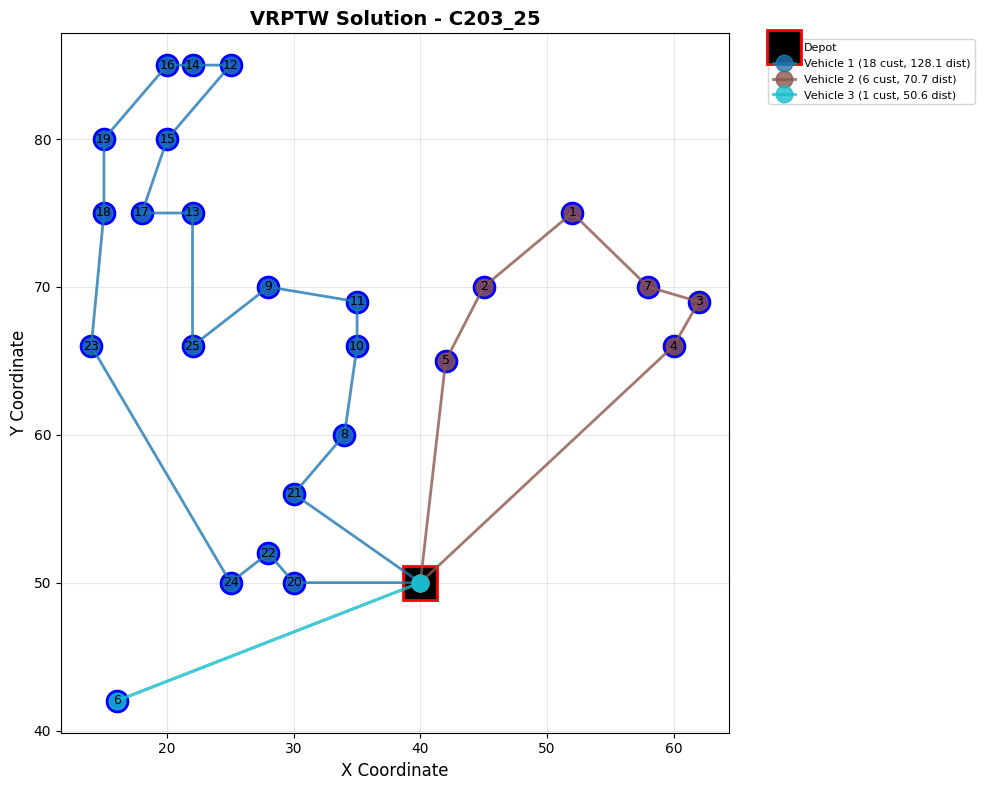


📊 Route Statistics:
Vehicle  Customers  Distance   Demand   Utilization 
------------------------------------------------------------
1        18         128.1      350      50.0        %
2        6          70.7       90       12.9        %
3        1          50.6       20       2.9         %
   Creating additional visualizations for C203_25...


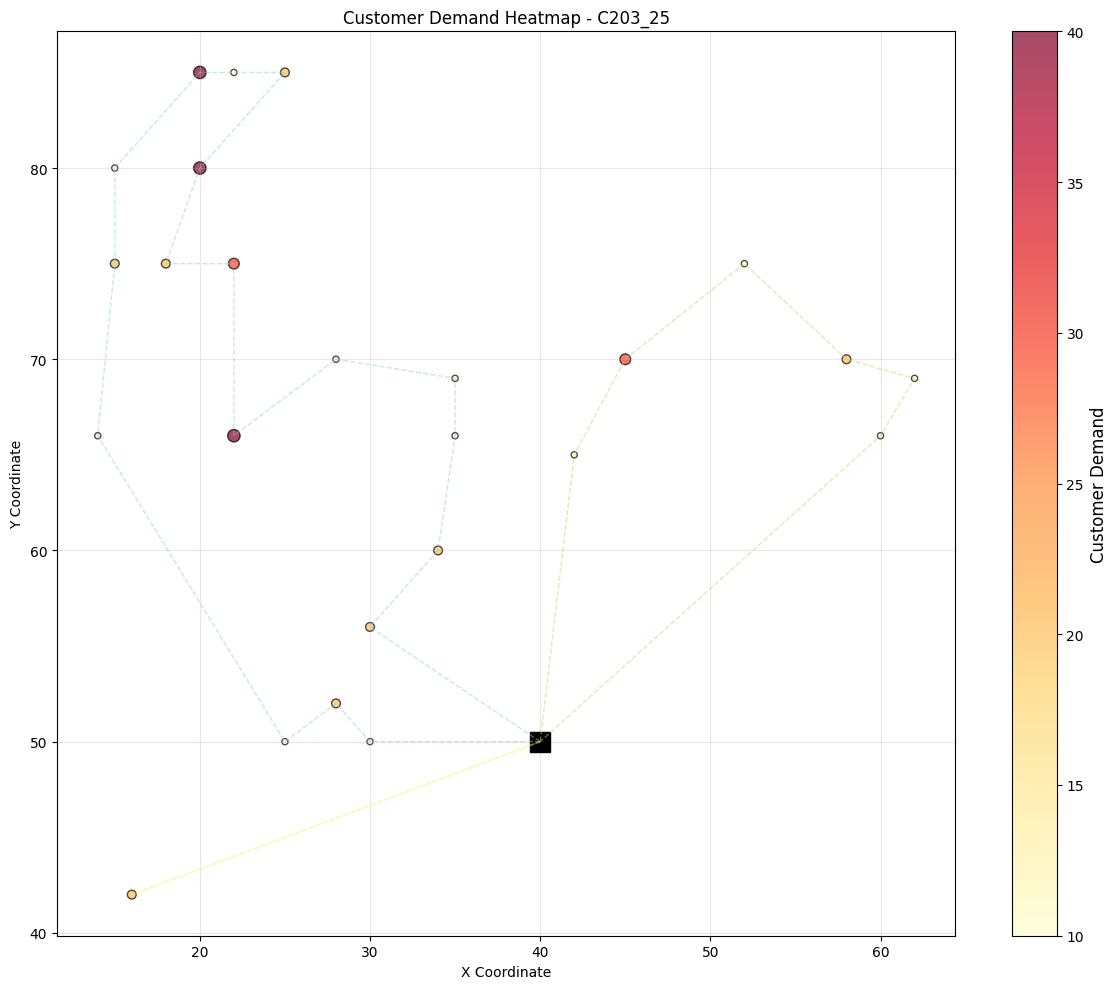

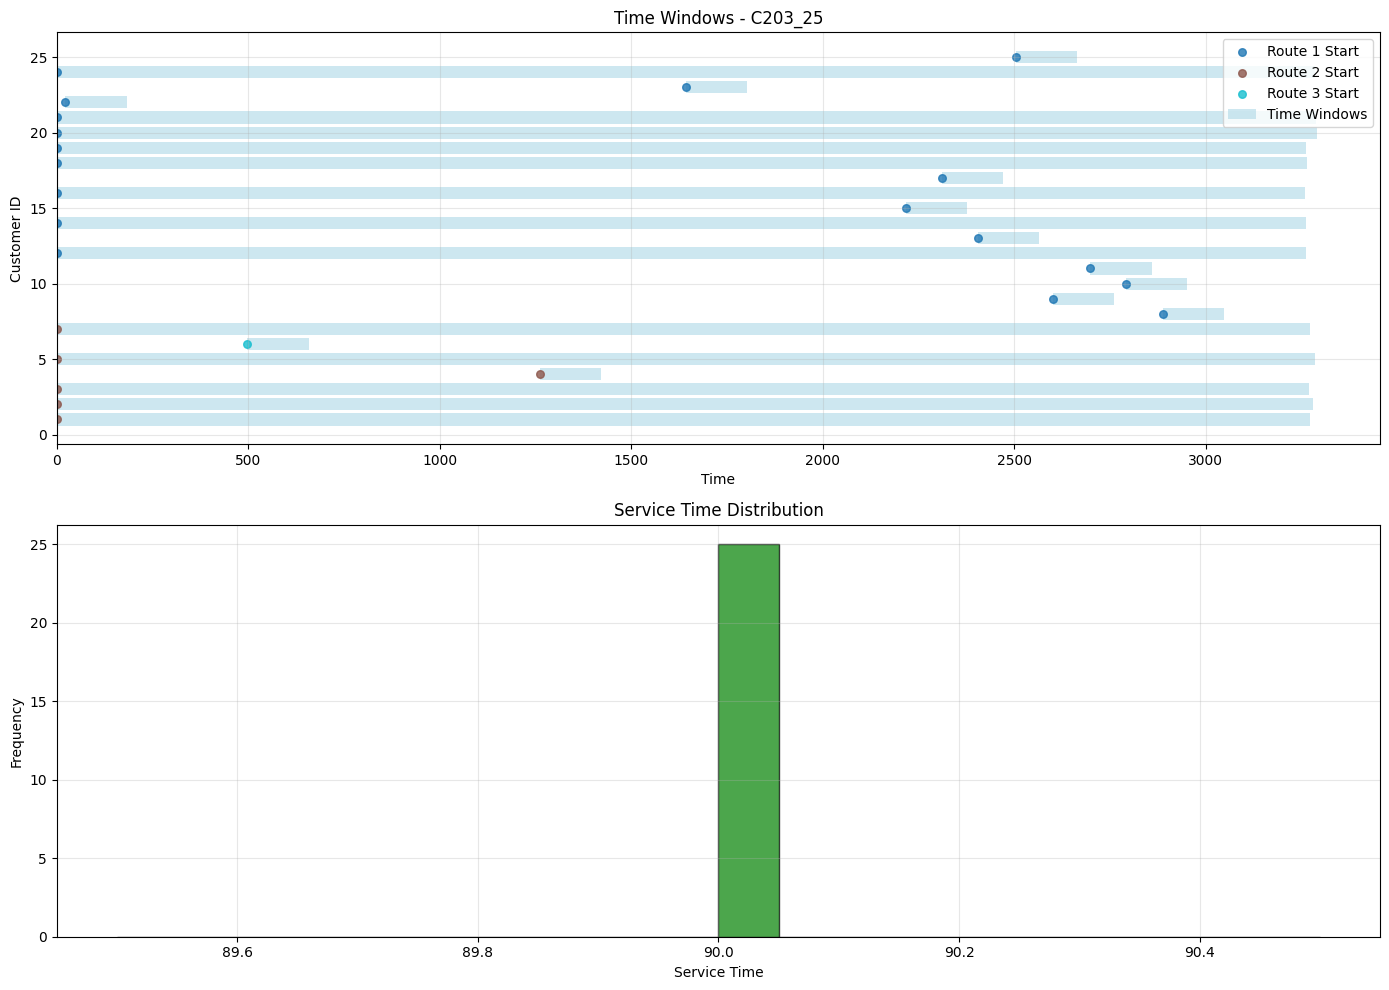

<Figure size 1400x800 with 0 Axes>

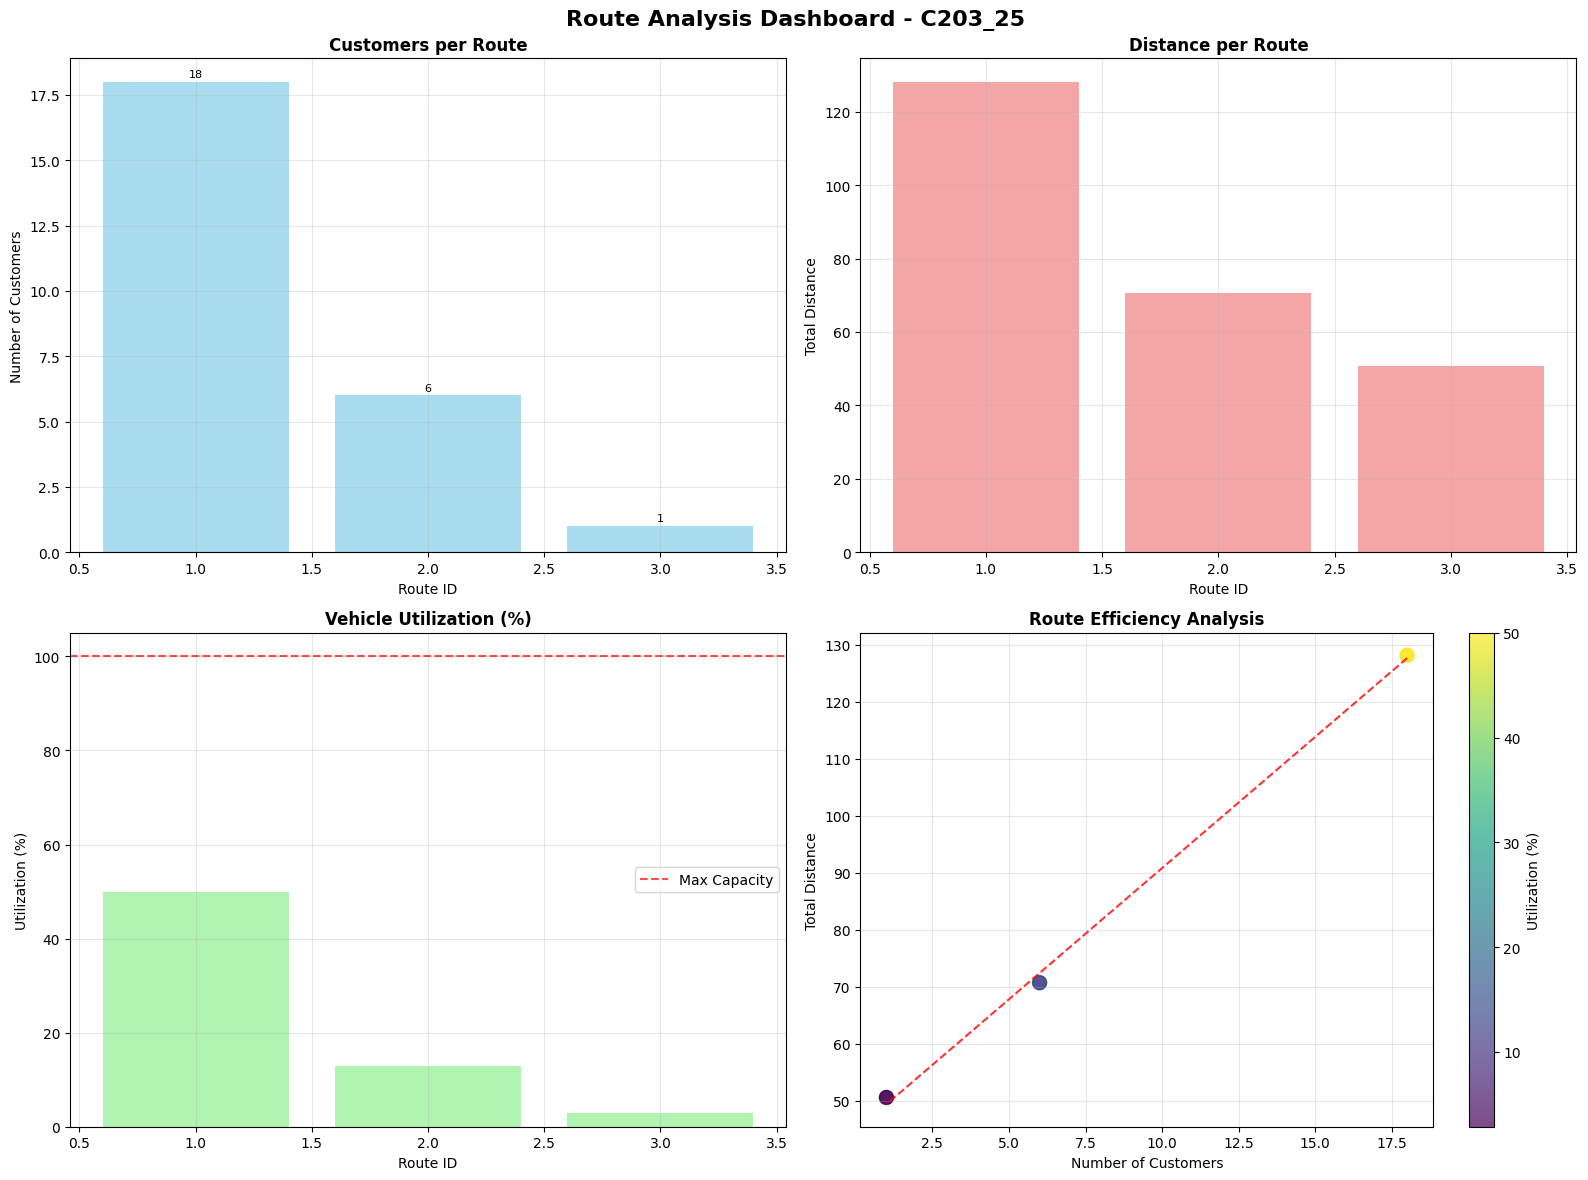


📈 Route Analysis Summary for C203_25:
  - Average customers per route: 8.3
  - Average distance per route: 83.1
  - Average utilization: 21.9%
  - Most efficient route: Route 1 (7.1 dist/customer)
  - Highest utilization: Route 1 (50.0%)

Processing C203_50...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 50 customers (requested: 50)
Successfully loaded C203_50:
  - Number of customers: 50
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=400, E=12
  - Time limit: 40 minutes
  - Priority: Complete coverage (100% customers)
Starting Enhanced Dynamic Programming for 50 customers...
DP Parameters: H=400 (max states), E=12 (max neighbors), Time limit: 40min
Multi-start configuration: 5 restarts for 50 customers
Restart 0, Iter 1: 1 states, Max coverage: 0/50, Time: 0.0s
Restart 0, Iter 2: 12 states, Max coverage: 1/50, Ti

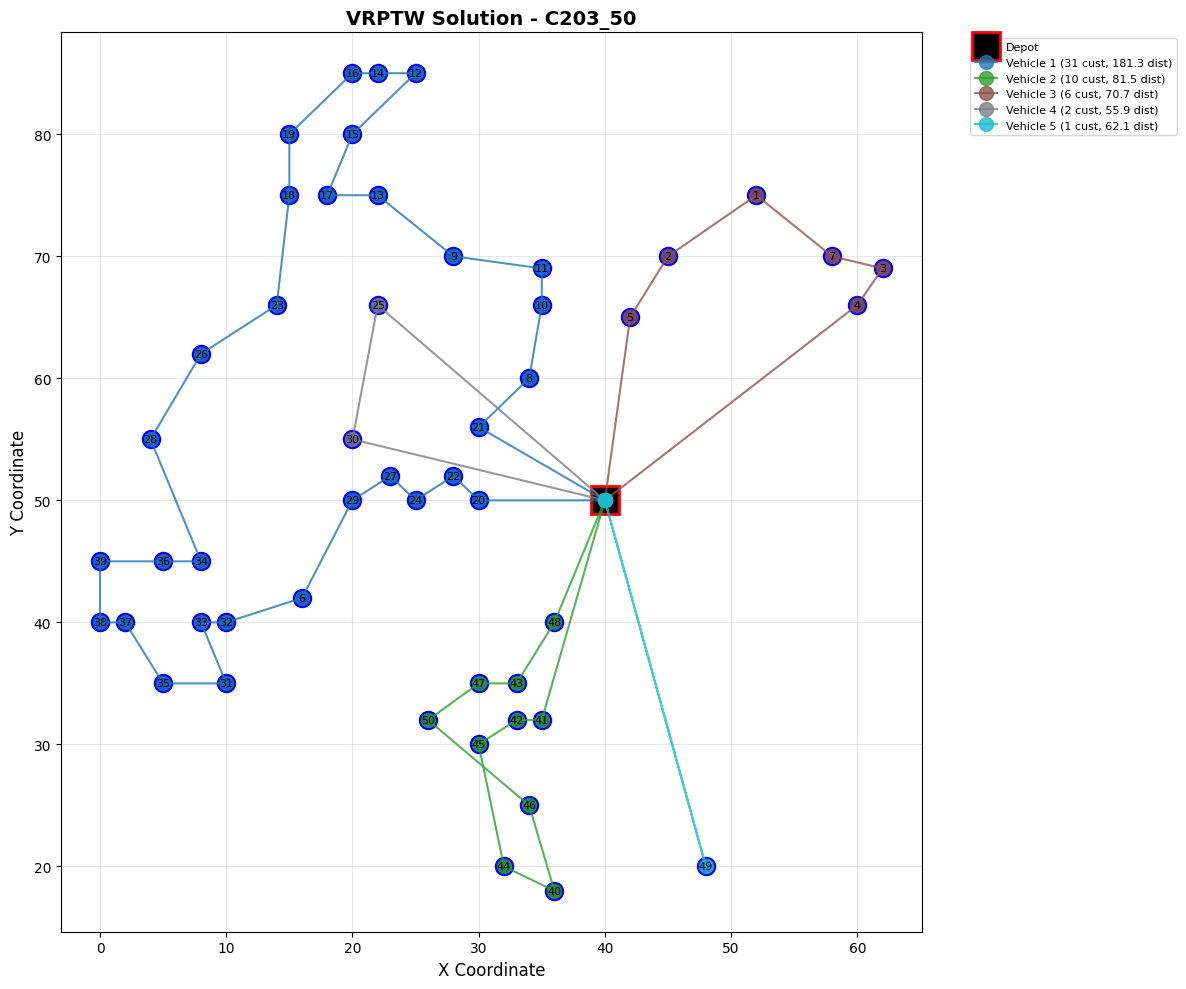


📊 Route Statistics:
Vehicle  Customers  Distance   Demand   Utilization 
------------------------------------------------------------
1        31         181.3      580      82.9        %
2        10         81.5       130      18.6        %
3        6          70.7       90       12.9        %
4        2          55.9       50       7.1         %
5        1          62.1       10       1.4         %
   Creating additional visualizations for C203_50...


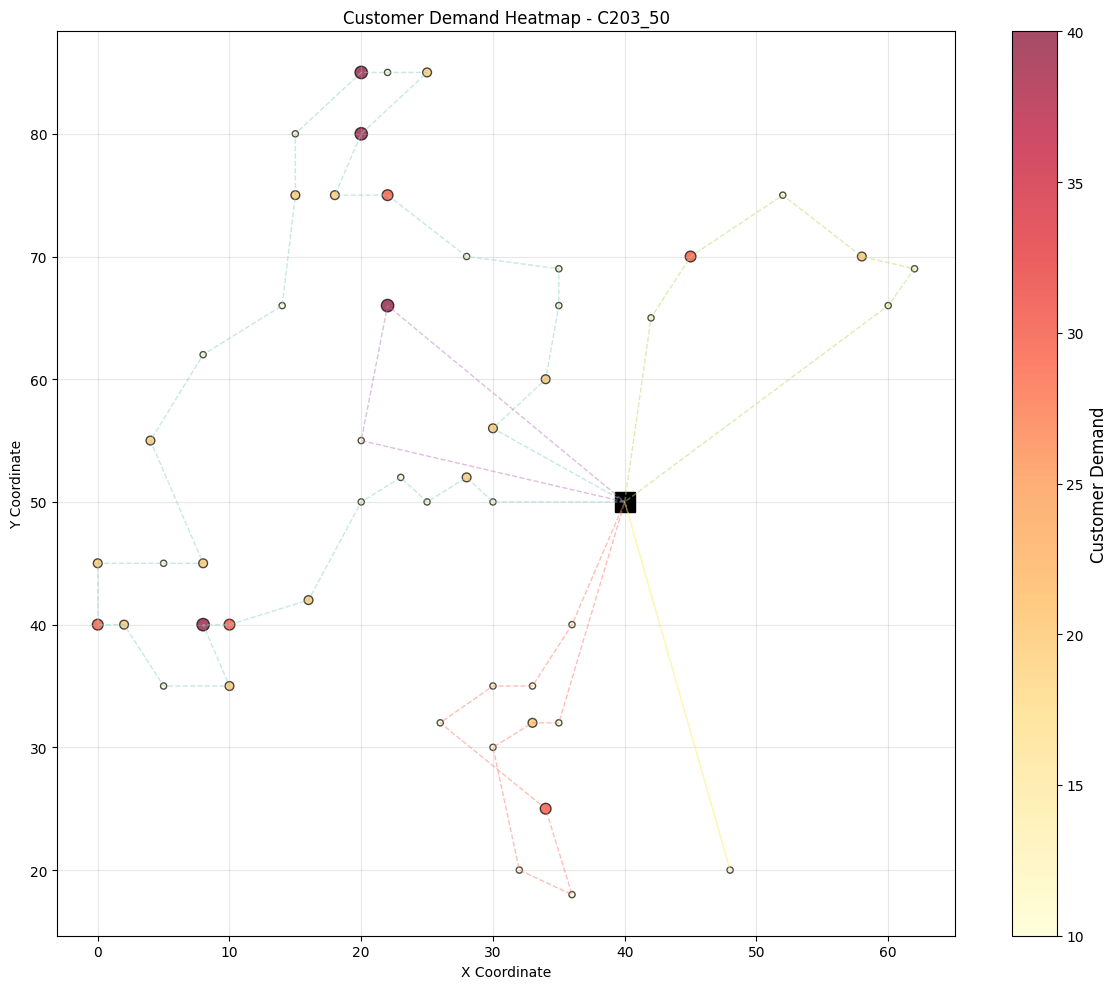

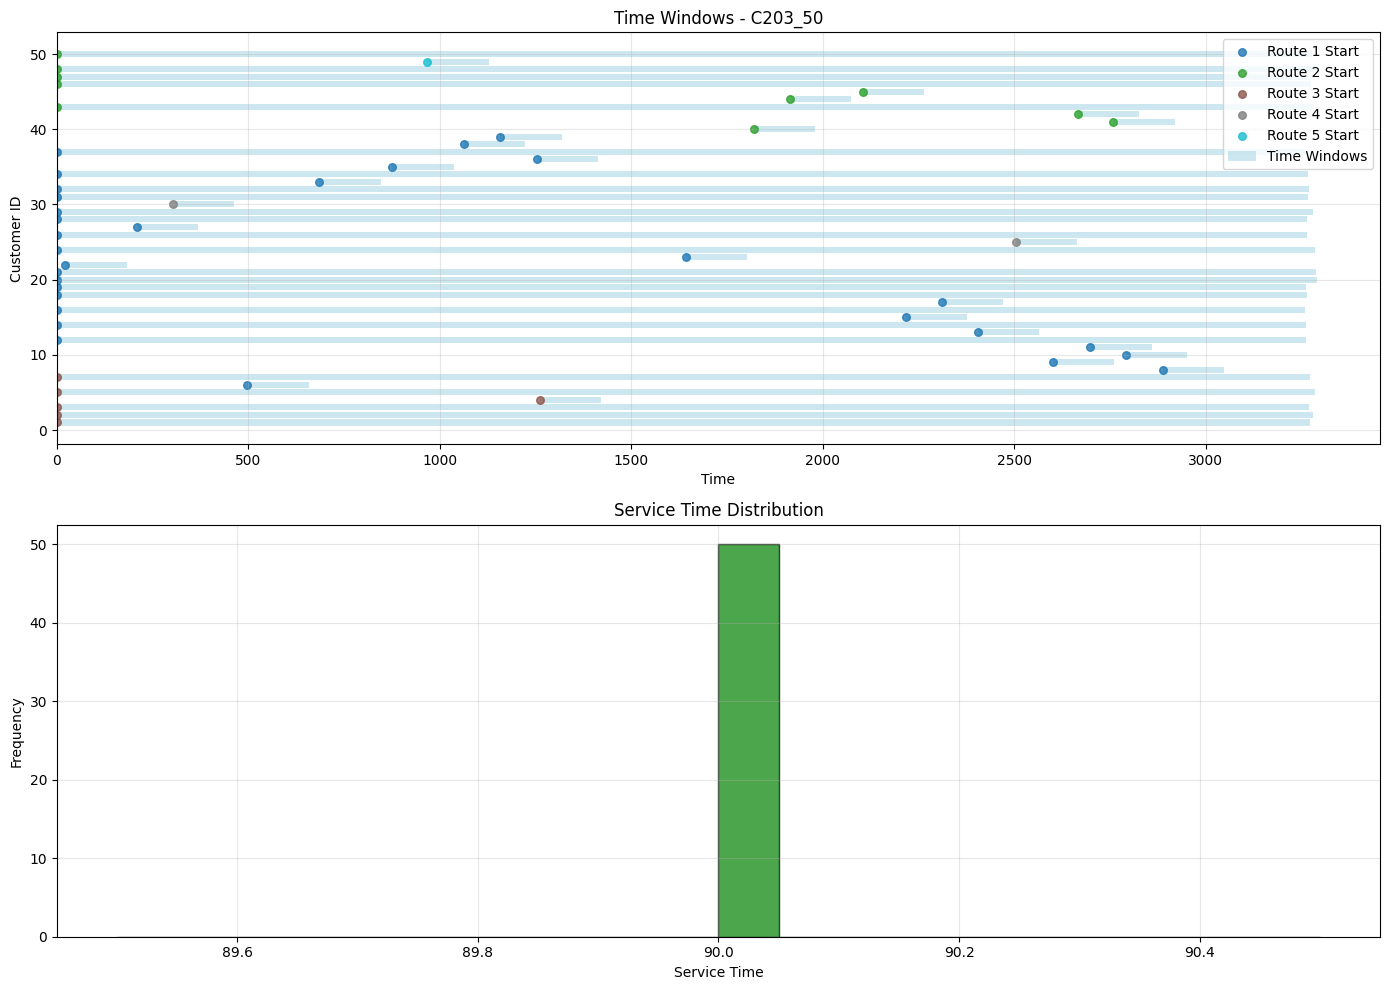

<Figure size 1400x800 with 0 Axes>

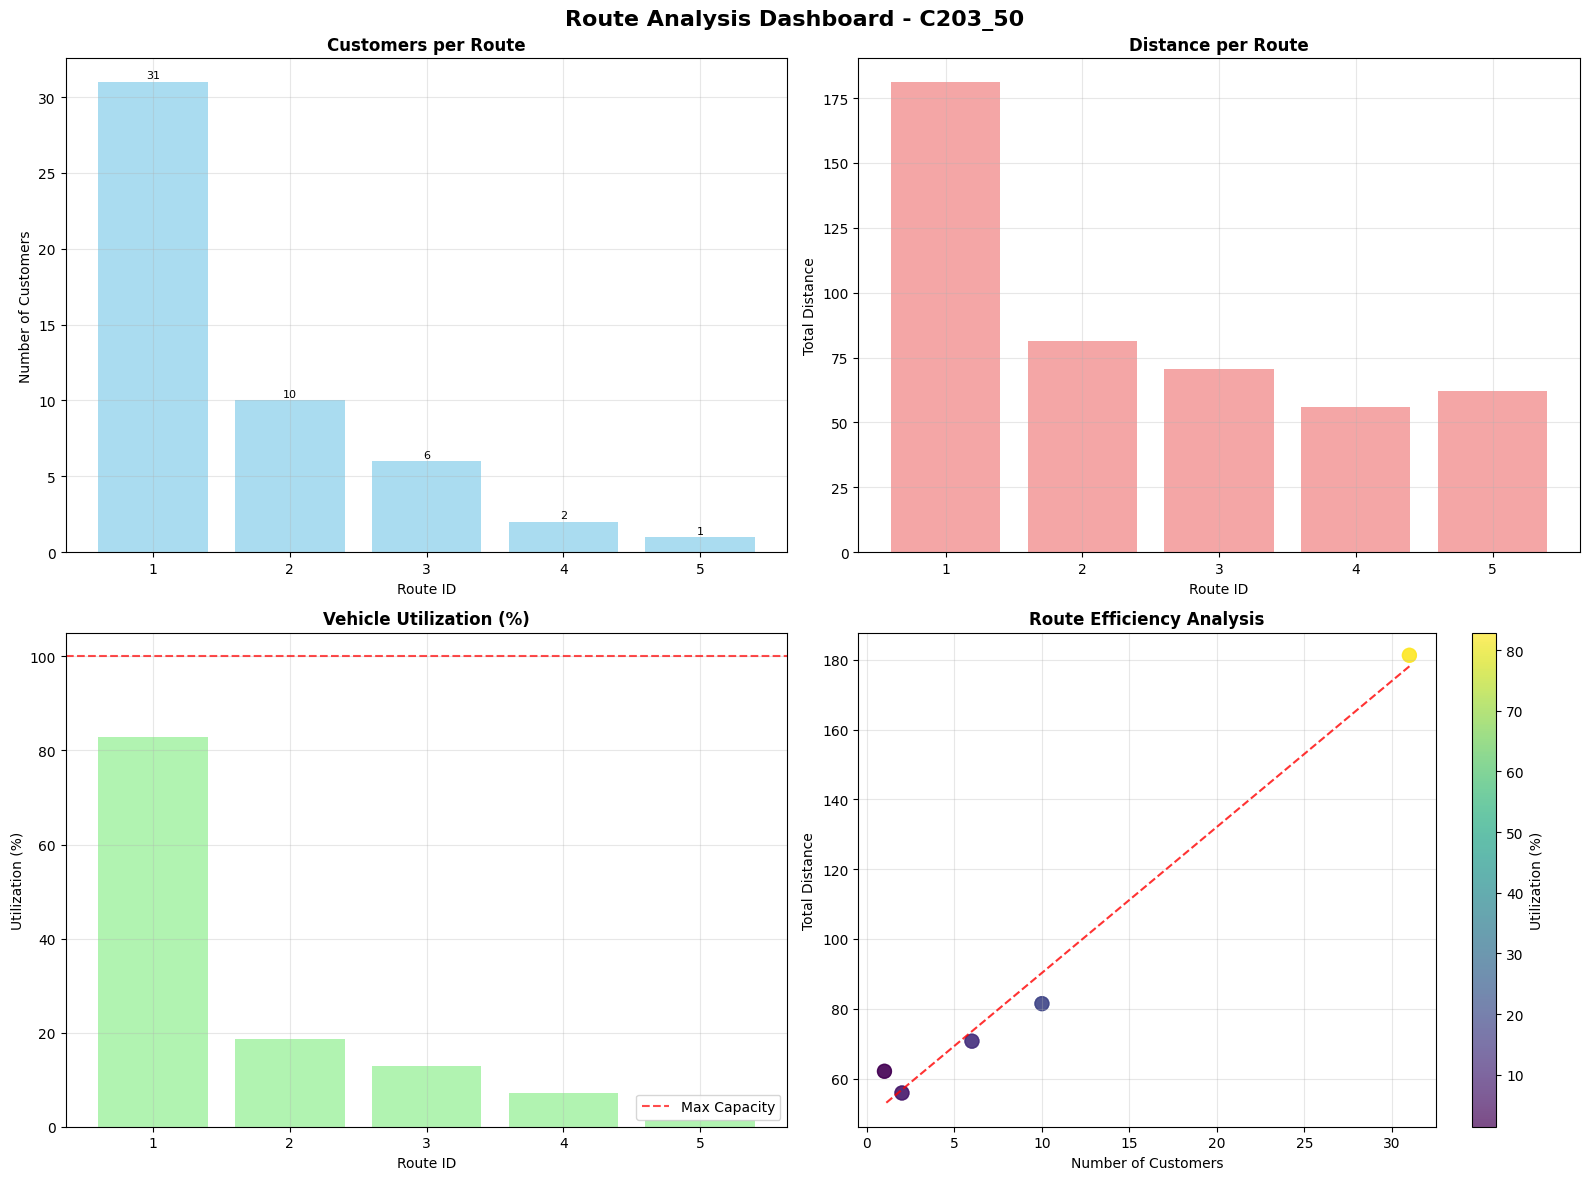


📈 Route Analysis Summary for C203_50:
  - Average customers per route: 10.0
  - Average distance per route: 90.3
  - Average utilization: 24.6%
  - Most efficient route: Route 1 (5.8 dist/customer)
  - Highest utilization: Route 1 (82.9%)

Processing C203_75...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 75 customers (requested: 75)
Successfully loaded C203_75:
  - Number of customers: 75
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=300, E=10
  - Time limit: 60 minutes
  - Priority: Complete coverage (100% customers)
Starting Enhanced Dynamic Programming for 75 customers...
DP Parameters: H=300 (max states), E=10 (max neighbors), Time limit: 60min
Multi-start configuration: 5 restarts for 75 customers
Restart 0, Iter 1: 1 states, Max coverage: 0/75, Time: 0.0s
Restart 0, Iter 2: 10 states, Max coverage: 1/75, T

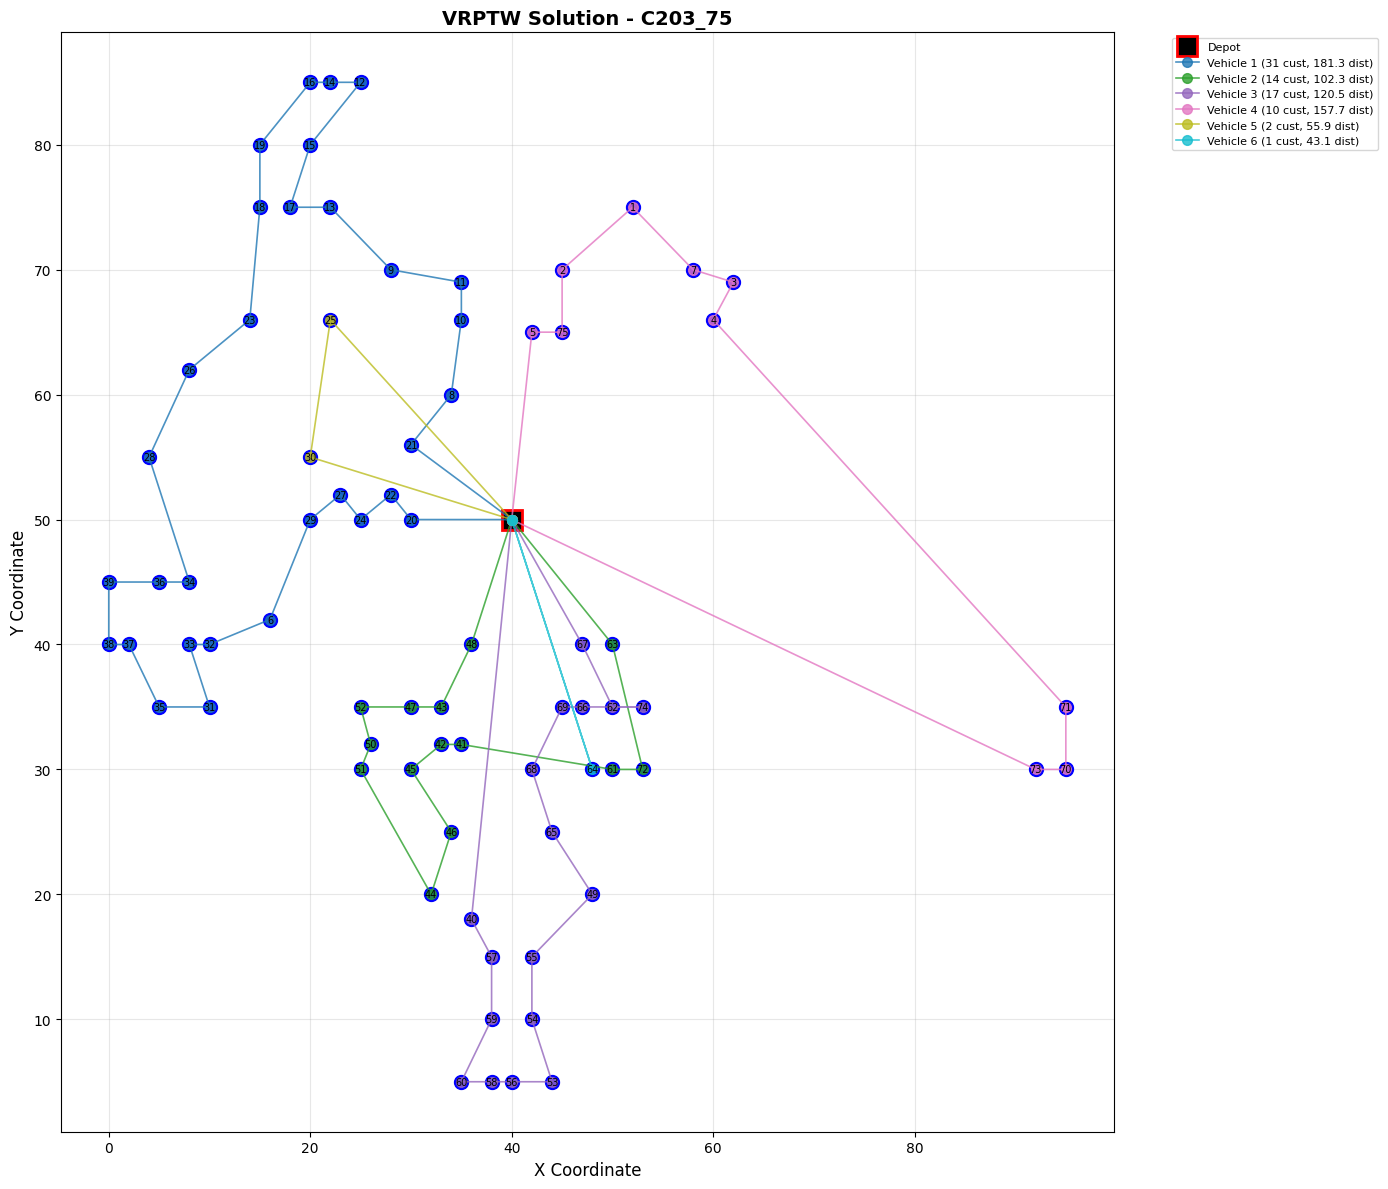


📊 Route Statistics:
Vehicle  Customers  Distance   Demand   Utilization 
------------------------------------------------------------
1        31         181.3      580      82.9        %
2        14         102.3      210      30.0        %
3        17         120.5      340      48.6        %
4        10         157.7      170      24.3        %
5        2          55.9       50       7.1         %
6        1          43.1       10       1.4         %
   Creating additional visualizations for C203_75...


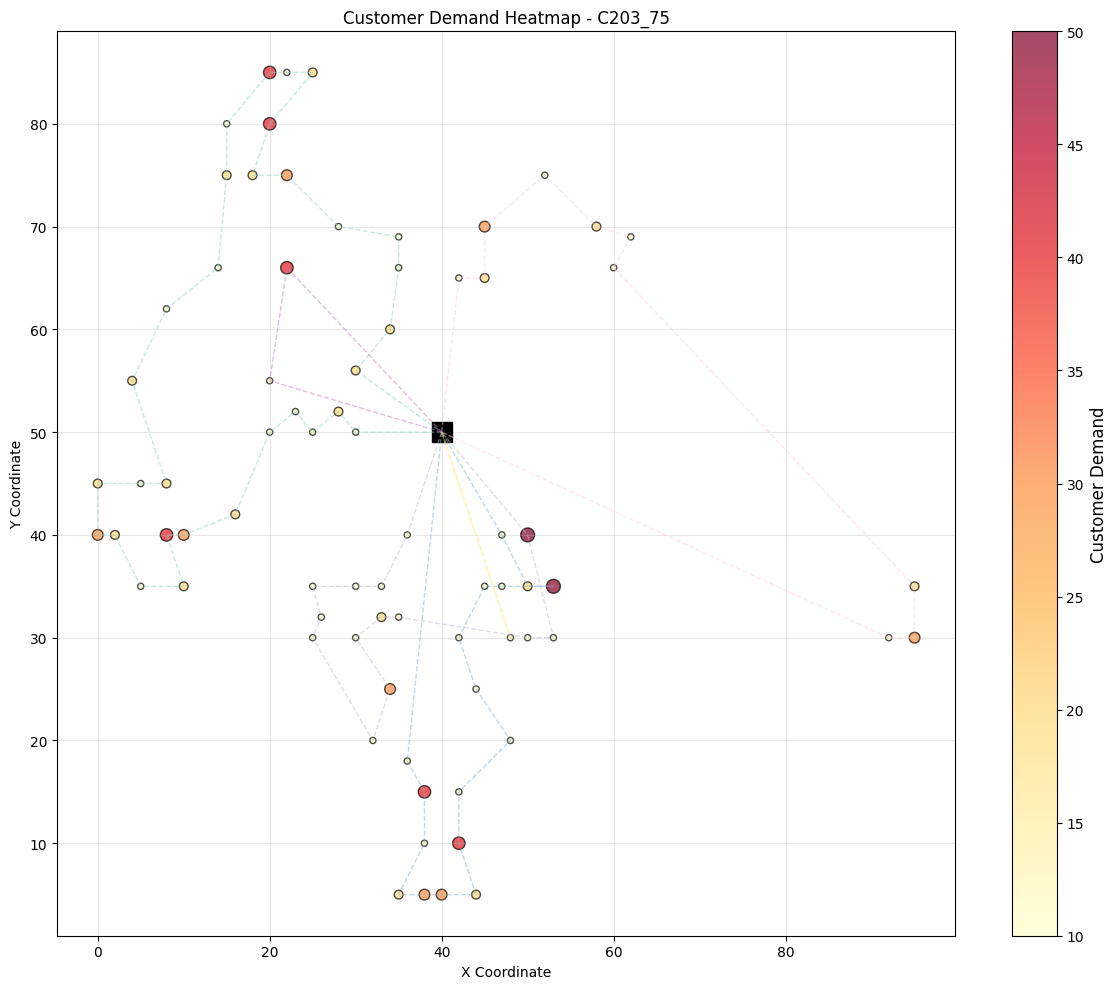

<Figure size 1400x800 with 0 Axes>

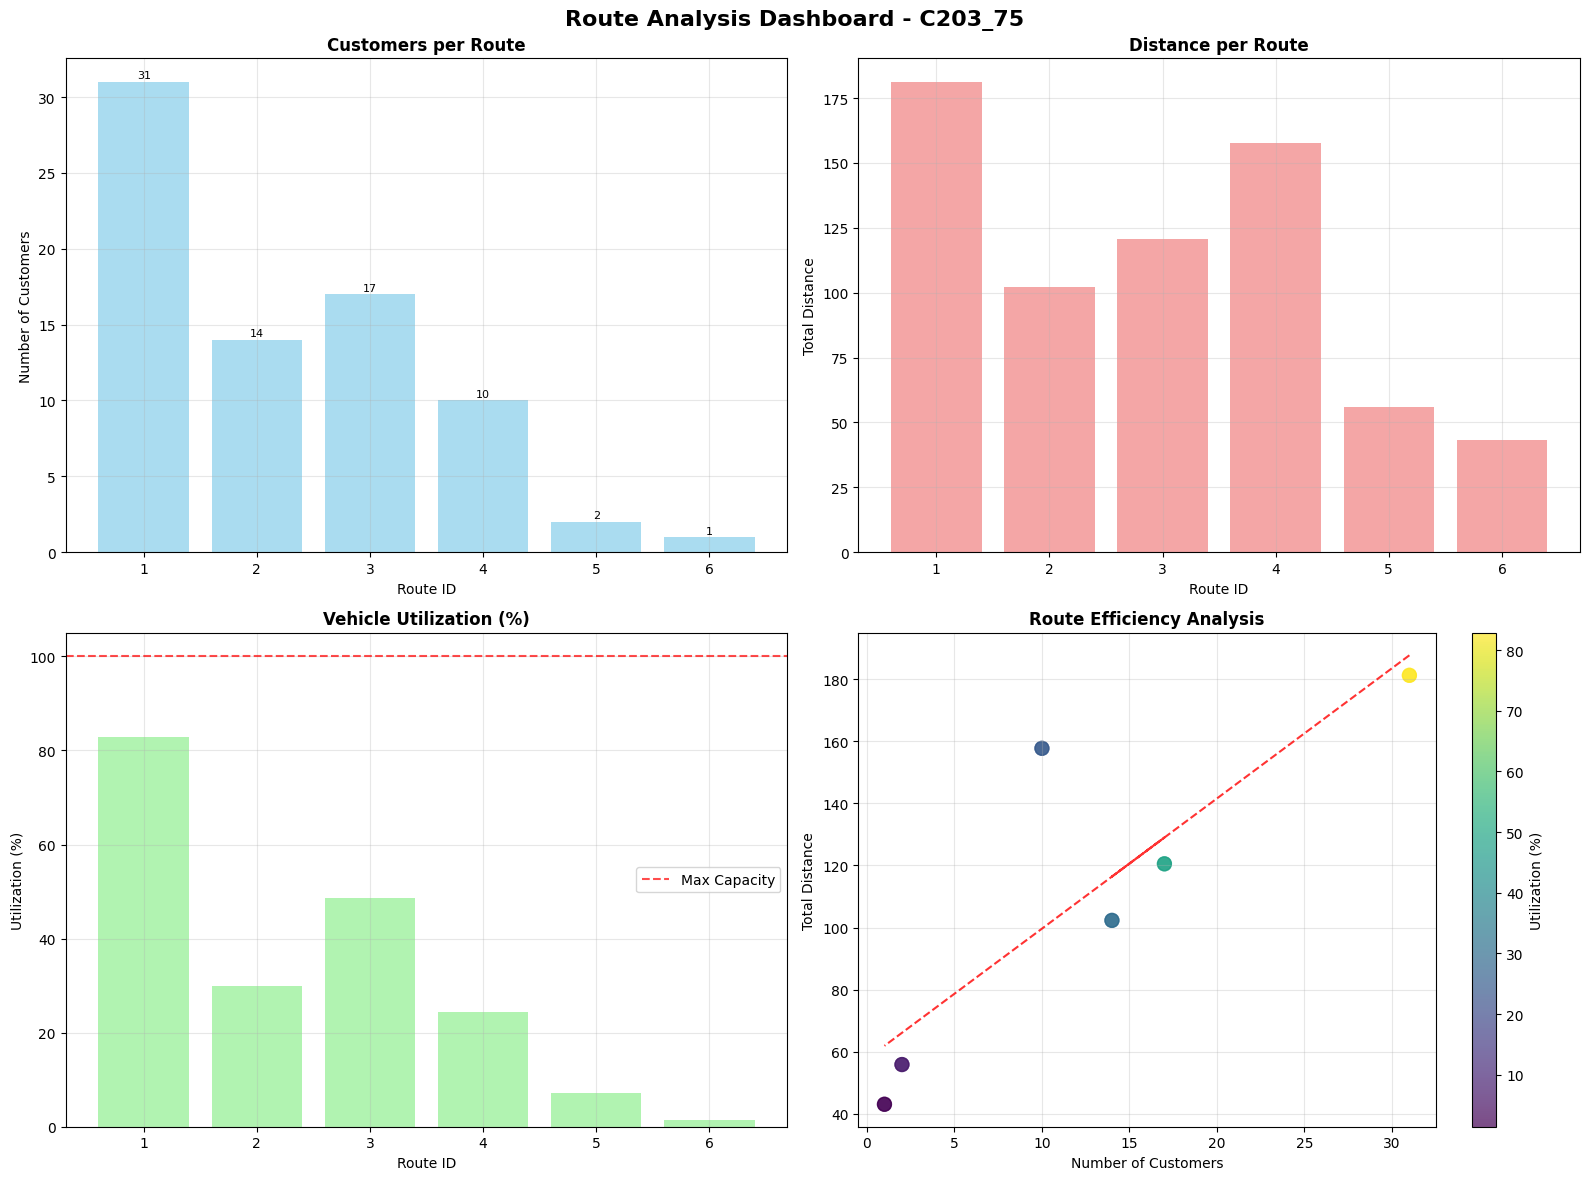


📈 Route Analysis Summary for C203_75:
  - Average customers per route: 12.5
  - Average distance per route: 110.1
  - Average utilization: 32.4%
  - Most efficient route: Route 1 (5.8 dist/customer)
  - Highest utilization: Route 1 (82.9%)

Processing C203_100...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '25         700'
  Parts: ['25', '700']
  Extracted capacity: 700
Loaded 100 customers (requested: 100)
Successfully loaded C203_100:
  - Number of customers: 100
  - Vehicle capacity: 700
  - Depot: (40.0, 50.0, 0.0, 3390.0)
  - Max vehicles allowed: 25
  - Algorithm parameters: H=250, E=8
  - Time limit: 80 minutes
  - Priority: Complete coverage (100% customers)
Starting Enhanced Dynamic Programming for 100 customers...
DP Parameters: H=250 (max states), E=8 (max neighbors), Time limit: 80min
Multi-start configuration: 5 restarts for 100 customers
Restart 0, Iter 1: 1 states, Max coverage: 0/100, Time: 0.0s
Restart 0, Iter 2: 8 states, Max coverage: 1

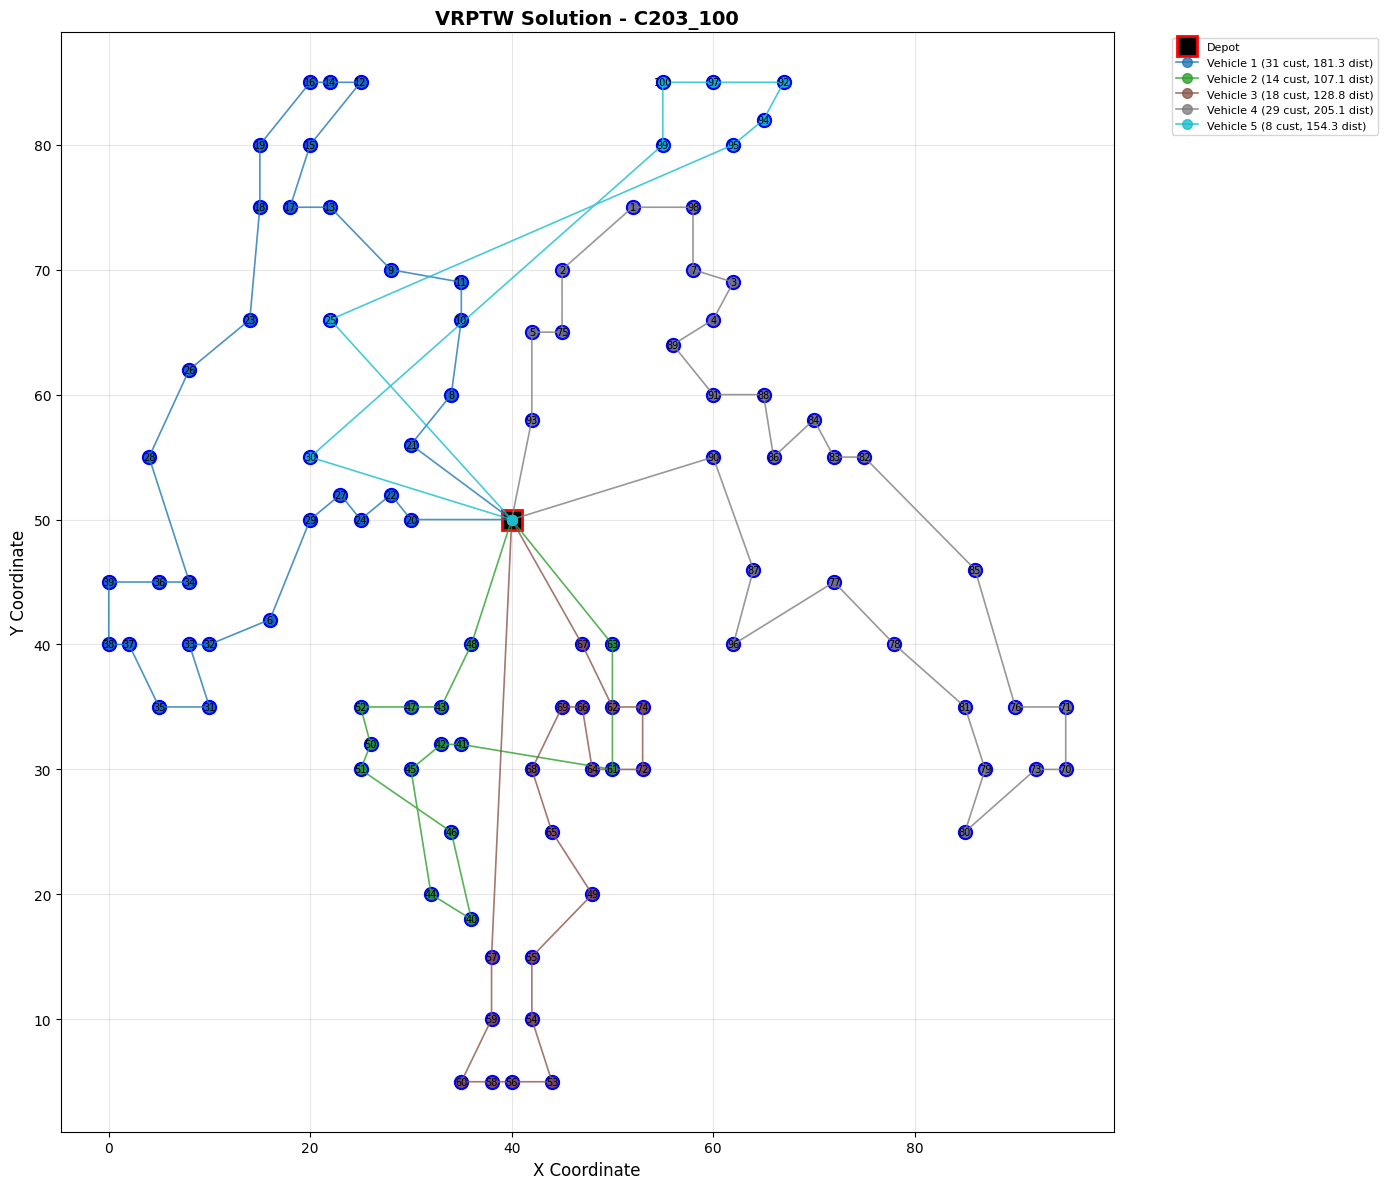


📊 Route Statistics:
Vehicle  Customers  Distance   Demand   Utilization 
------------------------------------------------------------
1        31         181.3      580      82.9        %
2        14         107.1      210      30.0        %
3        18         128.8      350      50.0        %
4        29         205.1      500      71.4        %
5        8          154.3      170      24.3        %
   Creating additional visualizations for C203_100...


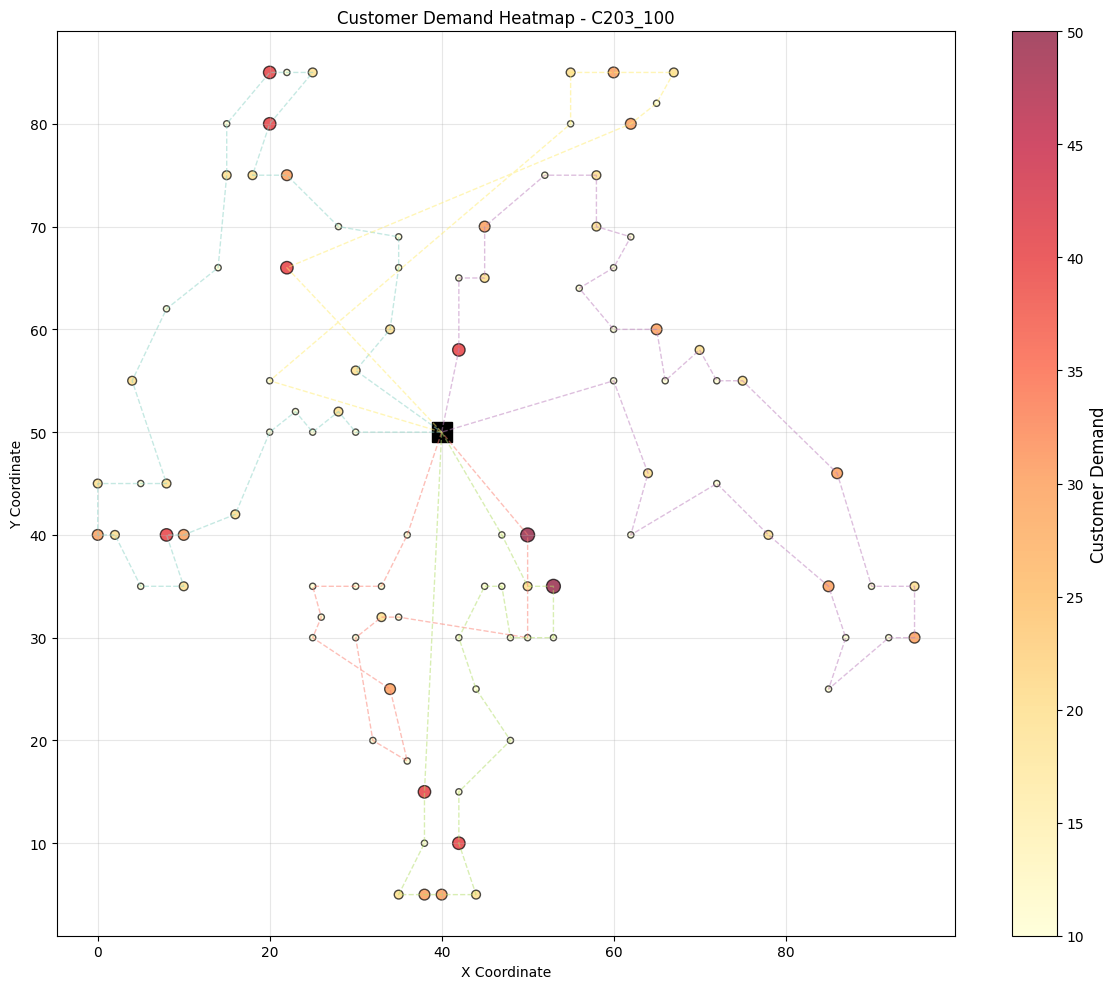

<Figure size 1400x800 with 0 Axes>

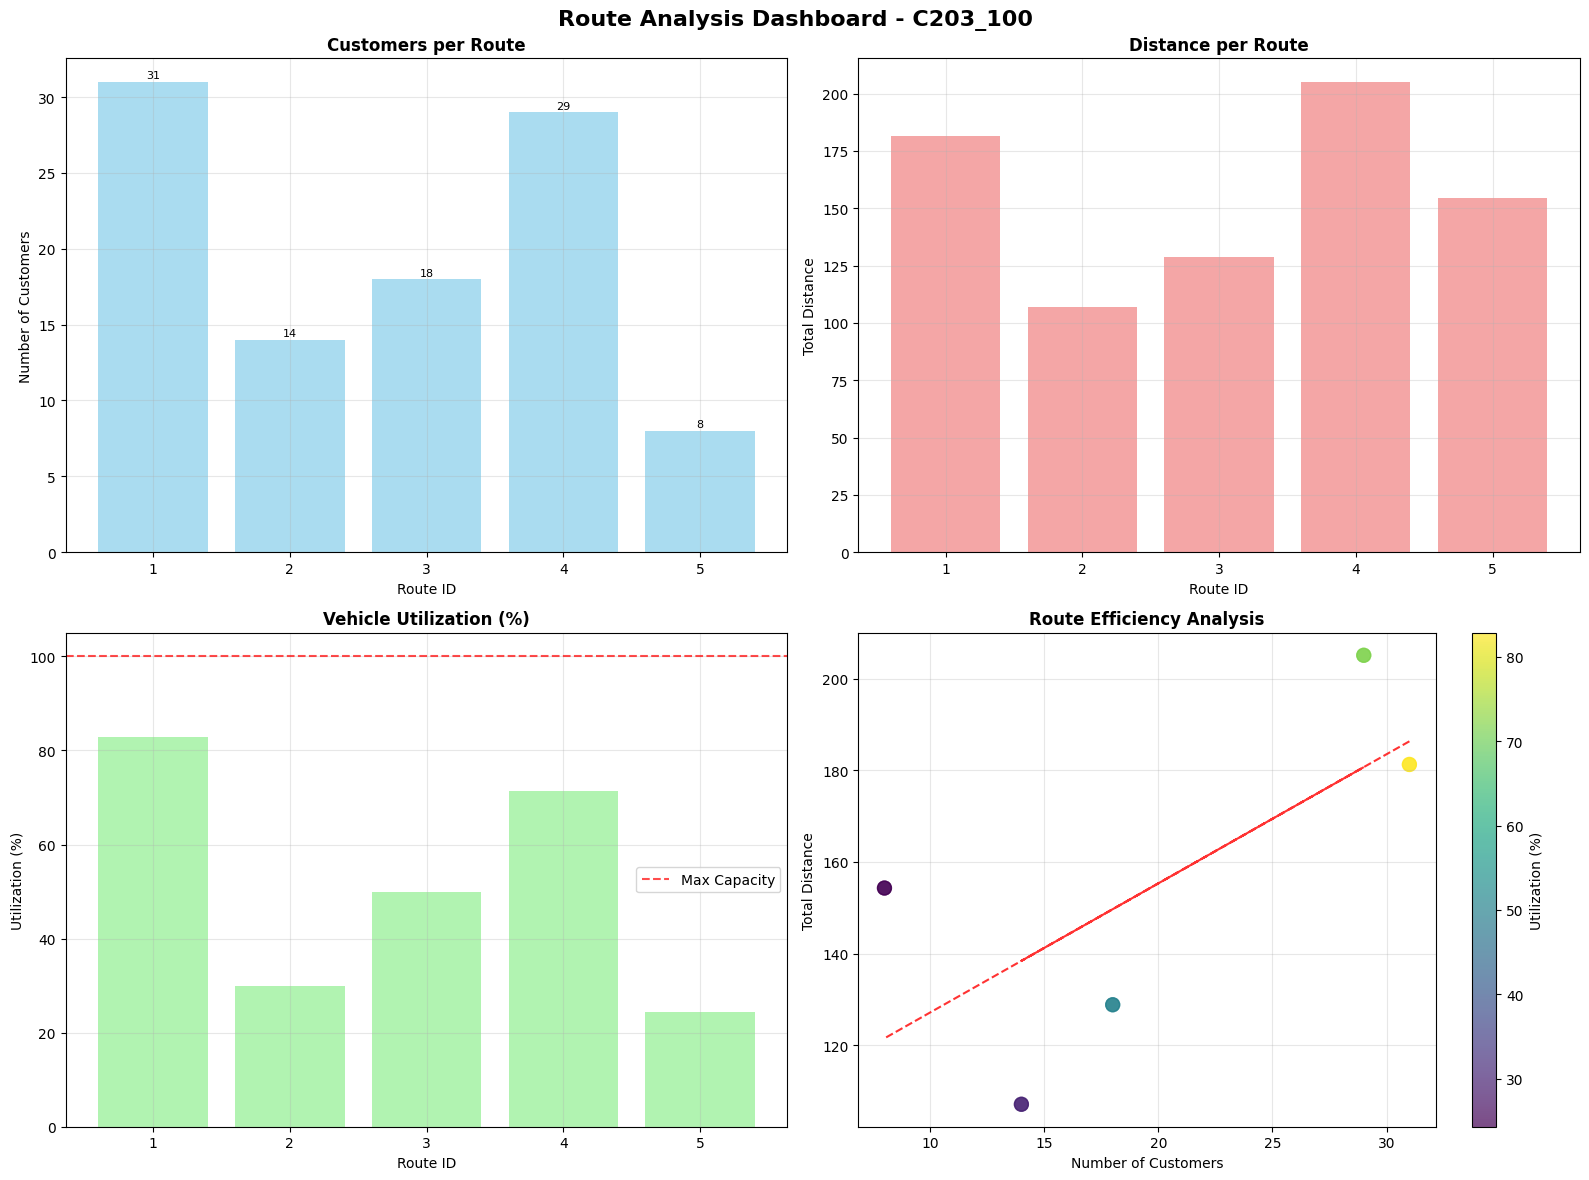


📈 Route Analysis Summary for C203_100:
  - Average customers per route: 20.0
  - Average distance per route: 155.3
  - Average utilization: 51.7%
  - Most efficient route: Route 1 (5.8 dist/customer)
  - Highest utilization: Route 1 (82.9%)

Processing R1_2_3_200...
VEHICLE section found:
  Header line: 'NUMBER     CAPACITY'
  Data line: '50          200'
  Parts: ['50', '200']
  Extracted capacity: 200
Loaded 200 customers (requested: 200)
Successfully loaded R1_2_3_200:
  - Number of customers: 200
  - Vehicle capacity: 200
  - Depot: (70.0, 70.0, 0.0, 634.0)
  - Max vehicles allowed: 50
  - Algorithm parameters: H=400, E=10
  - Time limit: 120 minutes
  - Priority: Complete coverage (100% customers)
Starting Enhanced Dynamic Programming for 200 customers...
DP Parameters: H=400 (max states), E=10 (max neighbors), Time limit: 120min
Multi-start configuration: 10 restarts for 200 customers
Restart 0, Iter 1: 1 states, Max coverage: 0/200, Time: 0.1s
Restart 0, Iter 2: 10 states, Max 

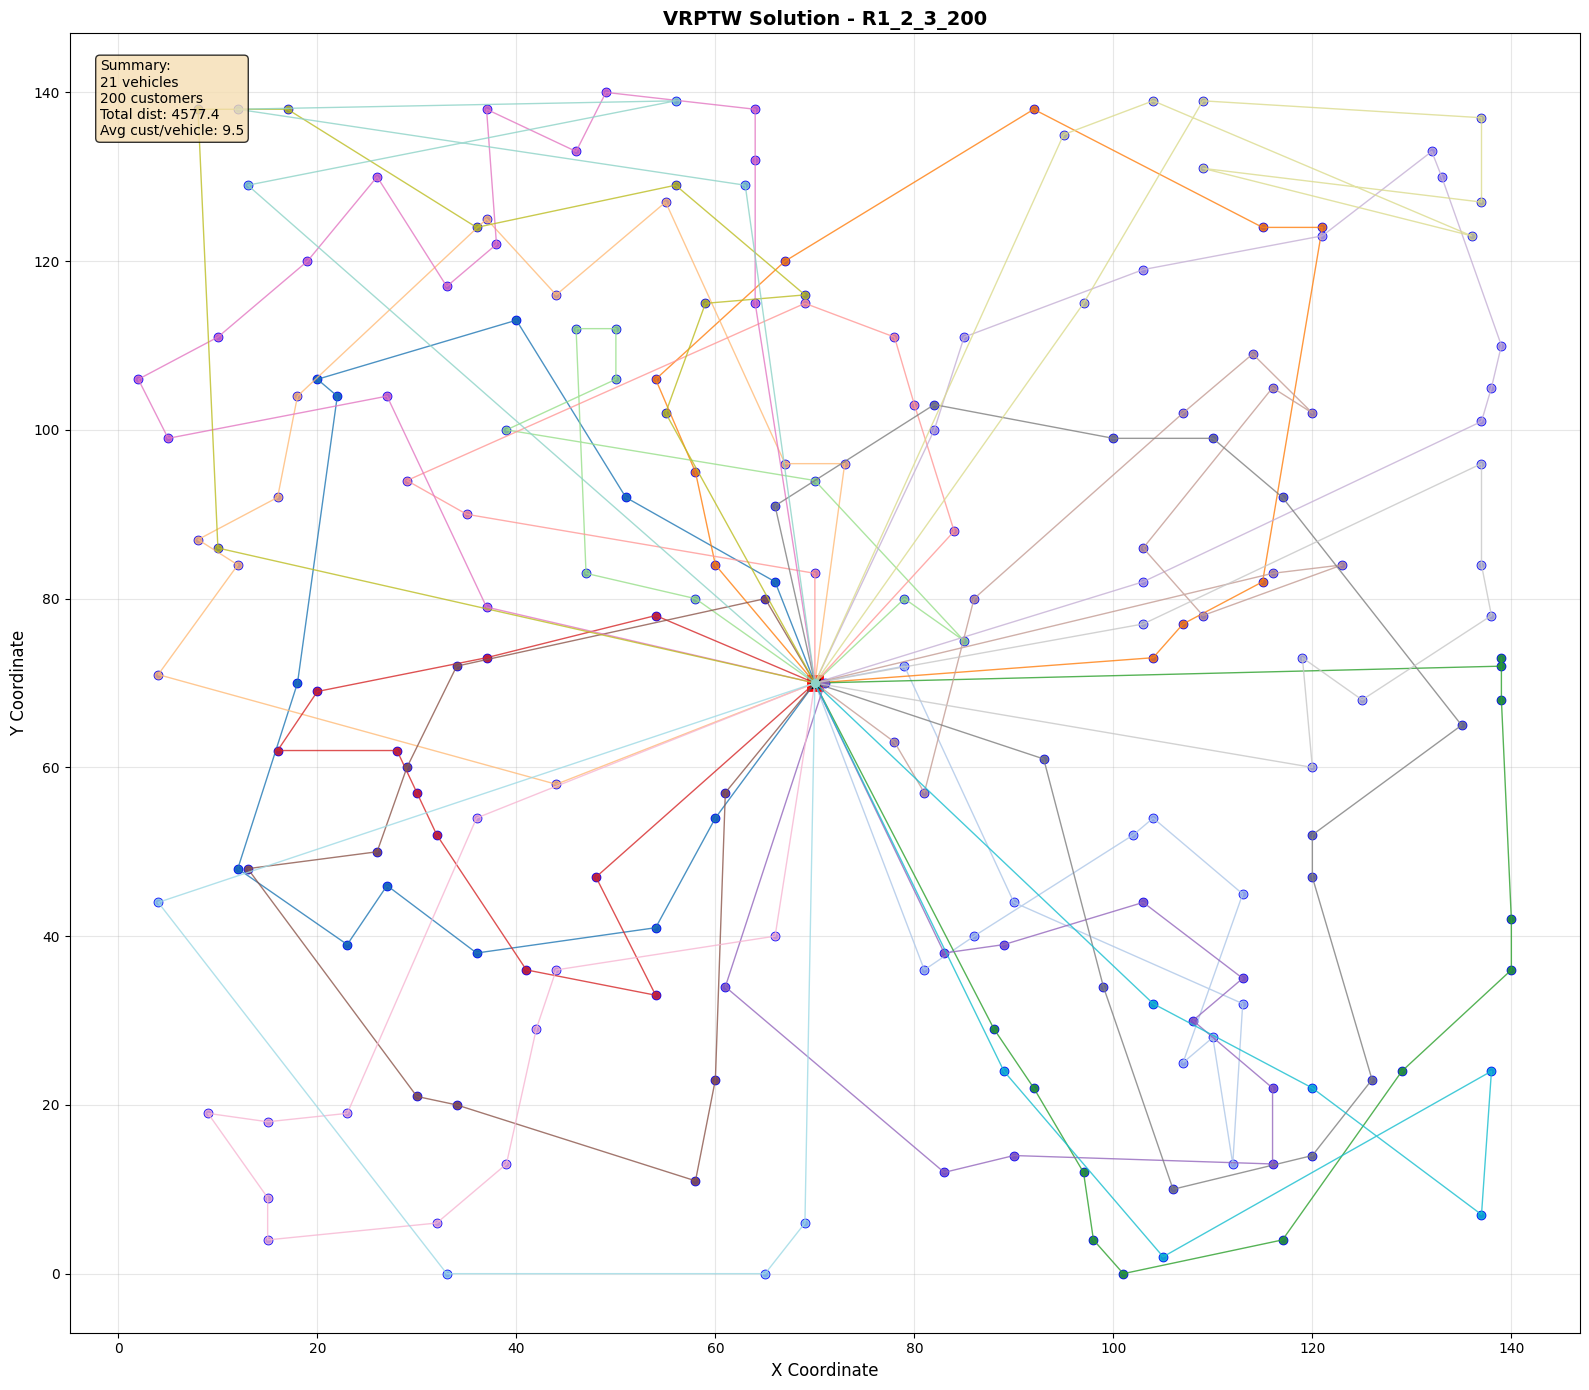


📊 Route Summary:
  - Total vehicles used: 21
  - Total customers served: 200
  - Total distance: 4577.4
  - Average utilization: 83.6%
  - Customers per vehicle: 9.5
   Creating simplified heatmap for large problem...


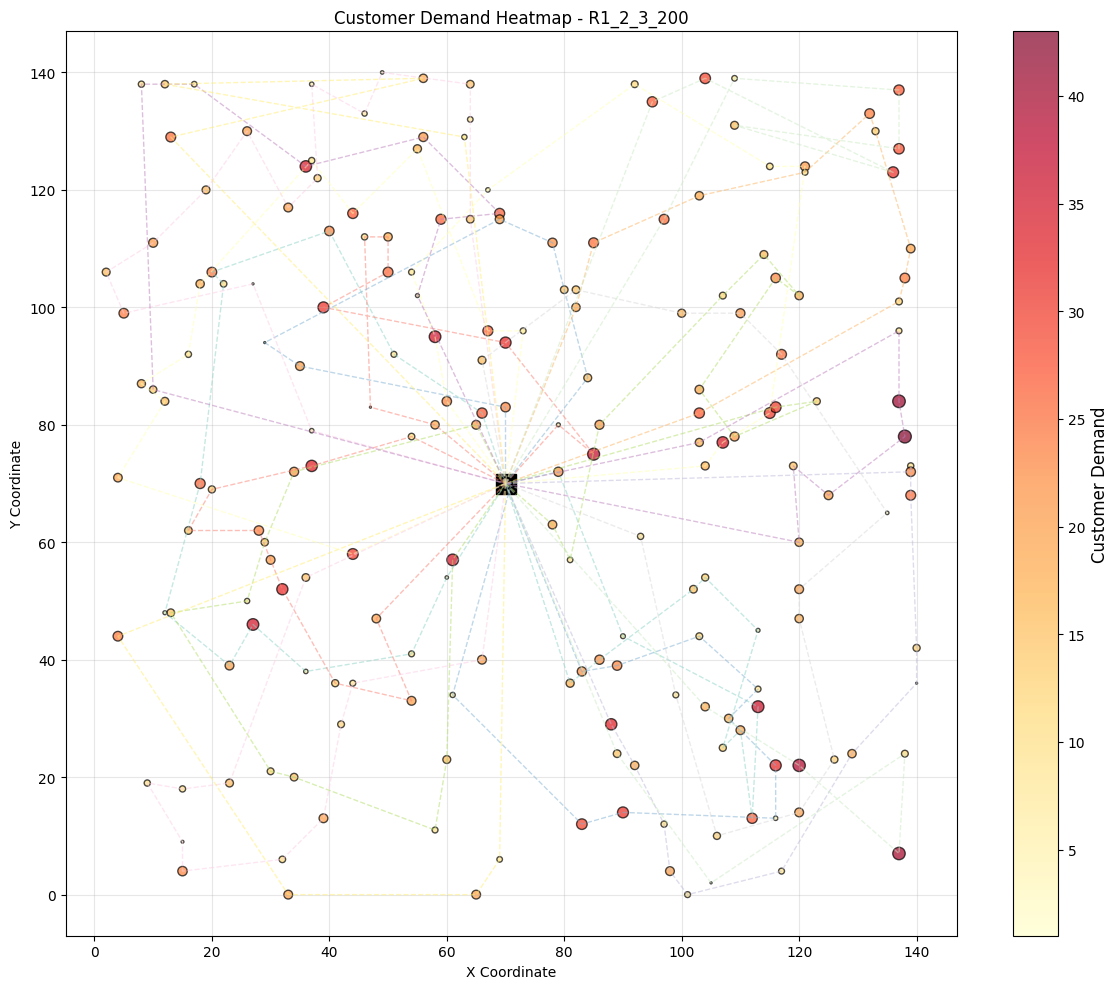


SUMMARY OF ALL TEST CASES:
Case            Time(s)  Vehicles     Coverage     Distance   Dataset   
----------------------------------------------------------------------------------------------------
C203_25         5.34     3/25         25/25        249.43     C203      
C203_50         6.67     5/25         50/50        451.42     C203      
C203_75         7.04     6/25         75/75        660.82     C203      
C203_100        6.41     5/25         100/100      776.61     C203      
R1_2_3_200      38.95    21/50        200/200      4577.38    R1_2_3    
----------------------------------------------------------------------------------------------------

📊 Creating summary comparison visualization...


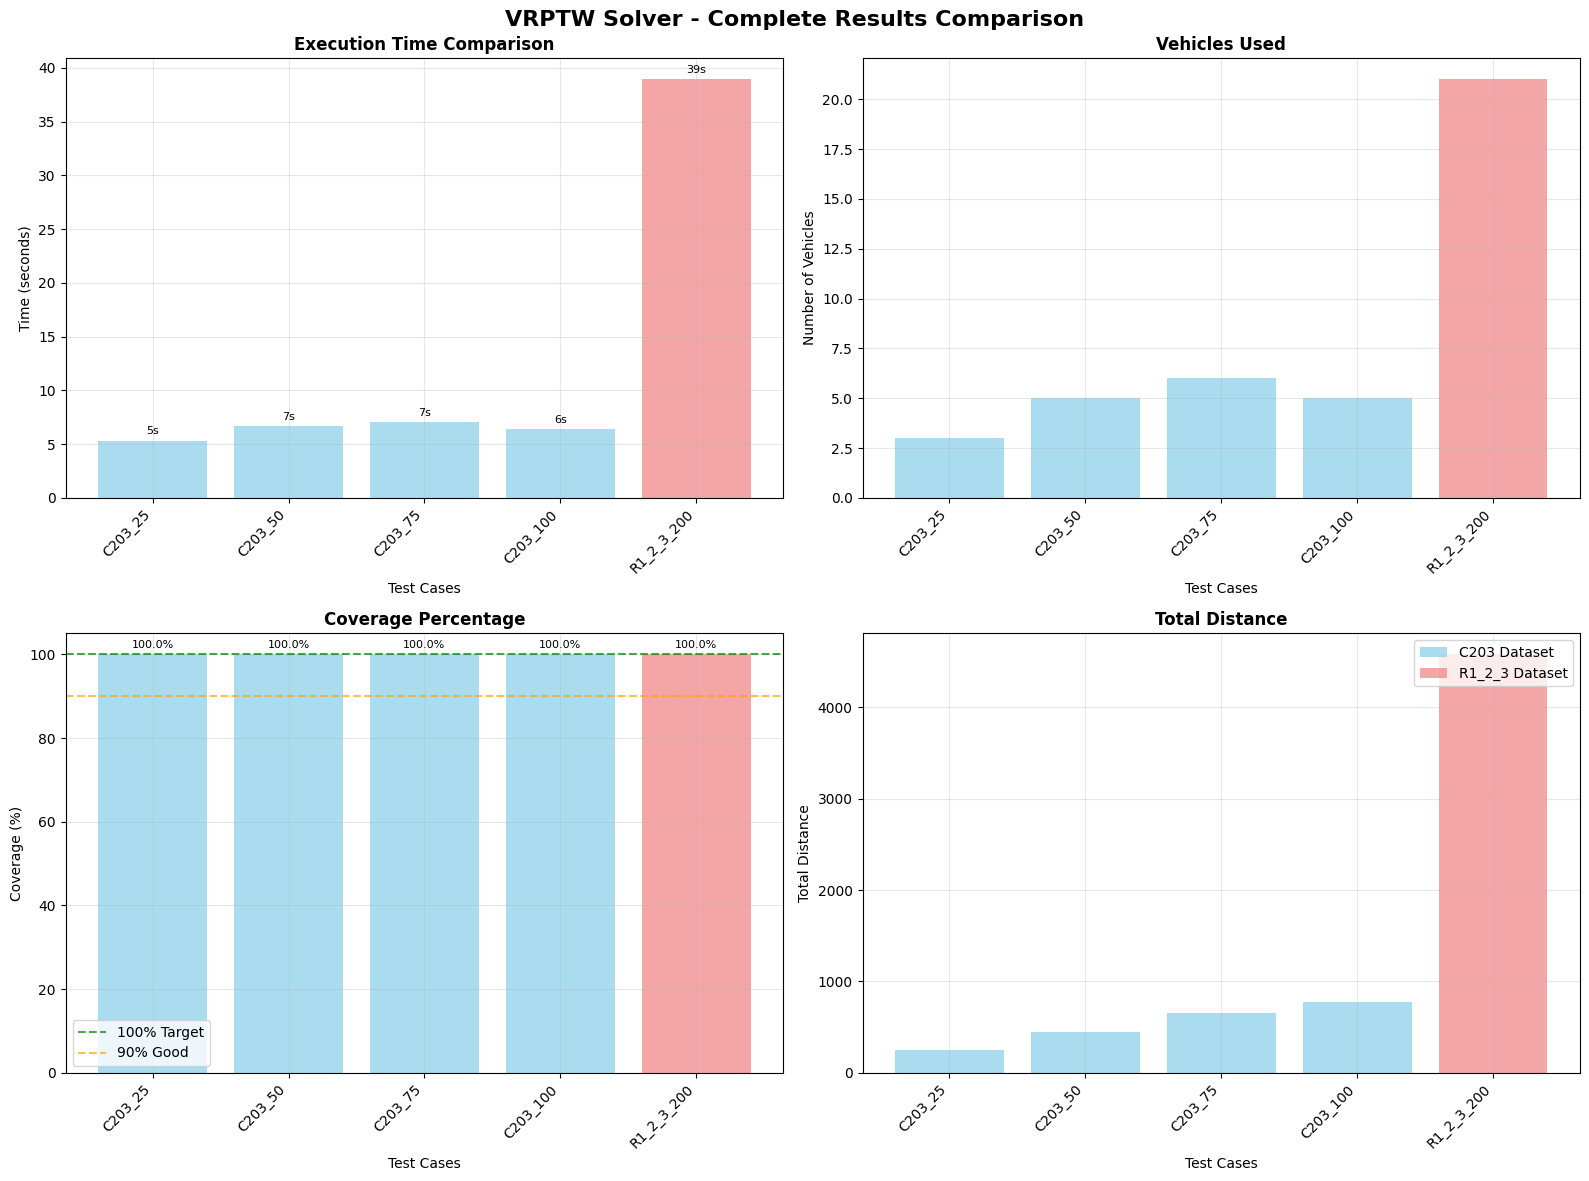


🎯 Performance Summary:
Case            Time(min)  Vehicles   Coverage   Distance   Efficiency  
--------------------------------------------------------------------------------
C203_25         0.1        3          100.0     % 249.4      10.0        
C203_50         0.1        5          100.0     % 451.4      9.0         
C203_75         0.1        6          100.0     % 660.8      8.8         
C203_100        0.1        5          100.0     % 776.6      7.8         
R1_2_3_200      0.6        21         100.0     % 4577.4     22.9        

🏆 Performance Insights:
  - Best Coverage: C203_25 (100.0%)
  - Fastest Execution: C203_25 (5.3s)
  - Most Efficient: C203_100 (7.8 dist/customer)
   Plot saved to: vrptw_summary_comparison.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# Hàm đọc dữ liệu từ file Solomon/Gehring-Homberger
def read_vrptw_instance(file_path, max_customers=None):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    node_coords = []
    demands = []
    time_windows = []
    service_times = []
    capacity = 0
    depot = None

    # Phân tích phần header
    i = 0
    while i < len(lines):
        line = lines[i].strip()

        if line == "VEHICLE":
            # Định dạng multi-line VEHICLE
            # Dòng tiếp theo: "NUMBER     CAPACITY"
            # Dòng sau đó: "  25         700"
            if i + 2 < len(lines):
                capacity_line = lines[i + 2].strip()
                parts = capacity_line.split()
                print(f"VEHICLE section found:")
                print(f"  Header line: '{lines[i + 1].strip()}'")
                print(f"  Data line: '{capacity_line}'")
                print(f"  Parts: {parts}")

                if len(parts) >= 2:
                    try:
                        capacity = int(parts[1])  # Capacity là phần tử thứ 2
                        print(f"  Extracted capacity: {capacity}")
                    except ValueError:
                        print(f"  Error: Could not parse capacity from '{parts[1]}'")
                        capacity = 200  # Default
            i += 3  # Skip the VEHICLE section

        elif line.startswith("VEHICLE"):
            # Định dạng single-line VEHICLE (fallback)
            parts = line.split()
            print(f"VEHICLE line: '{line}'")
            print(f"Parts: {parts}")
            print(f"Number of parts: {len(parts)}")

            # Try different common formats for VEHICLE capacity
            if len(parts) >= 6:  # Original format assumption
                capacity = int(parts[5])
            elif len(parts) >= 4:  # Alternative format: VEHICLE NUMBER CAPACITY xxx
                try:
                    capacity = int(parts[3])
                except ValueError:
                    capacity = int(parts[2])
            elif len(parts) >= 3:  # Another format: VEHICLE CAPACITY xxx
                try:
                    capacity = int(parts[2])
                except ValueError:
                    # Look for the first number in the line that could be capacity
                    for part in parts[1:]:
                        try:
                            capacity = int(part)
                            break
                        except ValueError:
                            continue

            print(f"Extracted capacity: {capacity}")
            i += 1

        elif line.startswith("CUSTOMER") or line.startswith("CUST NO."):
            i += 1
            break
        else:
            i += 1

    # Phân tích phần dữ liệu khách hàng
    customer_count = 0
    while i < len(lines):
        line = lines[i].strip()
        if line == "" or line.startswith("CUST"):
            i += 1
            continue

        parts = line.split()
        if len(parts) < 7:
            i += 1
            continue

        try:
            node_id = int(parts[0])
            x = float(parts[1])
            y = float(parts[2])
            demand = float(parts[3])
            ready = float(parts[4])
            due = float(parts[5])
            service = float(parts[6])

            if node_id == 0:  # Depot
                depot = (x, y, ready, due)
            else:
                # Kiểm tra giới hạn số lượng khách hàng
                if max_customers is None or customer_count < max_customers:
                    node_coords.append((x, y))
                    demands.append(demand)
                    time_windows.append((ready, due))
                    service_times.append(service)
                    customer_count += 1
                else:
                    break  # Đã đủ số lượng khách hàng yêu cầu
        except (ValueError, IndexError) as e:
            print(f"Error parsing line: '{line}' - {e}")

        i += 1

    # Fallback capacity if not found
    if capacity == 0:
        capacity = 200  # Default capacity
        print(f"Warning: Could not find vehicle capacity, using default: {capacity}")

    if depot is None:
        print("Error: Could not find depot information")
        return None

    actual_customers = len(demands)
    print(f"Loaded {actual_customers} customers (requested: {max_customers if max_customers else 'all'})")

    return {
        "depot": depot,
        "node_coords": node_coords,
        "demands": demands,
        "time_windows": time_windows,
        "service_times": service_times,
        "capacity": capacity,
        "num_customers": actual_customers
    }

# Hàm tính khoảng cách Euclid
def euclidean_distance(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

# Thuật toán Quy hoạch động giới hạn cho VRPTW với forced complete coverage
def vrptw_dp(data, H=1000, E=10, time_limit=3600):
    depot = data["depot"]
    coords = data["node_coords"]
    demands = data["demands"]
    time_windows = data["time_windows"]
    service_times = data["service_times"]
    capacity = data["capacity"]
    n = data["num_customers"]

    start_time = time.time()
    print(f"Starting Enhanced Dynamic Programming for {n} customers...")
    print(f"DP Parameters: H={H} (max states), E={E} (max neighbors), Time limit: {time_limit//60}min")

    # Tính ma trận khoảng cách
    dist_matrix = np.zeros((n+1, n+1))
    for i in range(n+1):
        for j in range(n+1):
            p1 = depot[:2] if i == 0 else coords[i-1]
            p2 = depot[:2] if j == 0 else coords[j-1]
            dist_matrix[i][j] = euclidean_distance(p1, p2)

    # Tối ưu: Tính trước nearest neighbors cho mỗi node
    nearest_neighbors = {}
    for i in range(n+1):
        neighbors = []
        for j in range(n+1):
            if i != j:
                neighbors.append((j, dist_matrix[i][j]))
        neighbors.sort(key=lambda x: x[1])
        nearest_neighbors[i] = neighbors

    best_complete_solution = None
    best_complete_cost = float('inf')
    best_coverage = 0
    best_partial_solution = None

    # Multi-start approach với forced diversification - đặc biệt tối ưu cho 200 customers
    restart_count = 0
    max_restarts = 10 if n >= 200 else 5  # Tăng restarts cho bài toán lớn

    print(f"Multi-start configuration: {max_restarts} restarts for {n} customers")

    while restart_count <= max_restarts:
        if restart_count > 0:
            print(f"\n🔄 Restart #{restart_count} - Forcing exploration of different customer sets...")

        # DP state: (visited_set, current_time, current_capacity, current_node)
        states = {}
        states[frozenset(), 0, capacity, 0] = {'cost': 0, 'parent': None, 'action': None}

        # Enhanced customer diversification cho bài toán lớn
        if restart_count > 0:
            priority_customers = list(range(1, n+1))
            np.random.seed(restart_count * 42)  # Deterministic randomness
            np.random.shuffle(priority_customers)

            if n >= 200:
                # Cho 200 customers: chia thành nhiều nhóm nhỏ hơn với overlap
                customers_per_restart = n // (max_restarts - 2)  # Overlap để đảm bảo coverage
                start_idx = max(0, (restart_count - 1) * customers_per_restart - 10)
                end_idx = min((restart_count) * customers_per_restart + 10, n)
            else:
                # Cho ít hơn 200 customers: logic cũ
                customers_per_restart = max(1, n // max_restarts)
                start_idx = (restart_count - 1) * customers_per_restart
                end_idx = min(restart_count * customers_per_restart, n)

            priority_set = set(priority_customers[start_idx:end_idx])
            print(f"   Priority customers for restart {restart_count}: {len(priority_set)} customers from {min(priority_set) if priority_set else 'none'} to {max(priority_set) if priority_set else 'none'}")
        else:
            priority_set = set()

        iteration = 0
        max_iterations = 300 if n >= 200 else 200  # Tăng iterations cho bài toán lớn

        while states and iteration < max_iterations:
            iteration += 1
            elapsed = time.time() - start_time

            if elapsed > time_limit:
                print(f"Time limit exceeded ({elapsed:.1f}s).")
                break

            # Tính max coverage hiện tại
            current_max_coverage = max([len(s[0]) for s in states.keys()]) if states else 0

            print(f"Restart {restart_count}, Iter {iteration}: {len(states)} states, Max coverage: {current_max_coverage}/{n}, Time: {elapsed:.1f}s")

            new_states = {}

            # Nhóm states theo coverage level để đảm bảo diversity
            coverage_groups = {}
            for state_key, state_value in states.items():
                visited_set, time_val, cap_val, node = state_key
                coverage = len(visited_set)
                if coverage not in coverage_groups:
                    coverage_groups[coverage] = []
                coverage_groups[coverage].append((state_key, state_value))

            # Xử lý từng nhóm coverage
            total_states_processed = 0
            for coverage_level in sorted(coverage_groups.keys(), reverse=True):
                group_states = coverage_groups[coverage_level]

                # Ưu tiên states có coverage cao hơn với allocation linh hoạt
                if coverage_level == max(coverage_groups.keys()):
                    # Coverage cao nhất gets 50% of H
                    states_to_process = min(H // 2, len(group_states))
                else:
                    # Các coverage khác chia đều phần còn lại
                    remaining_groups = len(coverage_groups) - 1
                    if remaining_groups > 0:
                        states_to_process = min((H // 2) // remaining_groups, len(group_states))
                    else:
                        states_to_process = min(H // 4, len(group_states))

                # Đảm bảo ít nhất process một số states tối thiểu
                states_to_process = max(states_to_process, min(5, len(group_states)))

                # Giới hạn tổng số states processed
                if total_states_processed + states_to_process > H:
                    states_to_process = max(1, H - total_states_processed)

                # Sắp xếp theo cost trong nhóm
                group_states.sort(key=lambda x: x[1]['cost'])
                selected_group_states = group_states[:states_to_process]
                total_states_processed += len(selected_group_states)

                for state_key, state_value in selected_group_states:
                    visited_set, time_val, cap_val, node = state_key
                    cost = state_value['cost']

                    # Kiểm tra nếu đã ghé thăm tất cả khách hàng
                    if len(visited_set) == n:
                        return_cost = cost + dist_matrix[node][0]
                        if return_cost < best_complete_cost:
                            best_complete_cost = return_cost
                            best_complete_solution = (state_key, state_value)
                            print(f"  🎉 Found COMPLETE solution: cost={return_cost:.2f}, coverage=100%")
                        continue

                    # Lưu best partial solution
                    if len(visited_set) > best_coverage:
                        best_coverage = len(visited_set)
                        best_partial_solution = (state_key, state_value)

                    # Tìm customers chưa được ghé thăm
                    unvisited = set(range(1, n+1)) - visited_set

                    # Forced exploration: Đảm bảo có ít nhất một expansion cho mỗi unvisited customer
                    if restart_count > 0 and len(unvisited) > 0:
                        # Ưu tiên priority customers trong restart này
                        priority_unvisited = unvisited & priority_set
                        if priority_unvisited:
                            unvisited = list(priority_unvisited) + list(unvisited - priority_unvisited)
                        else:
                            unvisited = list(unvisited)
                    else:
                        unvisited = list(unvisited)

                    # Neighbor selection với enhanced diversity cho bài toán lớn
                    neighbors = []
                    checked_count = 0

                    # Tăng số neighbors checked cho bài toán lớn
                    if n >= 200:
                        max_check = min(len(unvisited), E * 5)  # Tăng mạnh cho 200 customers
                        urgency_weight = 50  # Tăng trọng số urgency
                        coverage_weight = 200  # Tăng trọng số coverage bonus
                    elif n >= 100:
                        max_check = min(len(unvisited), E * 4)
                        urgency_weight = 30
                        coverage_weight = 150
                    else:
                        max_check = min(len(unvisited), E * 3)
                        urgency_weight = 20
                        coverage_weight = 100

                    for customer in unvisited:
                        if checked_count >= max_check:
                            break

                        travel_time = dist_matrix[node][customer]
                        arrival_time = time_val + travel_time
                        ready, due = time_windows[customer-1]
                        service_time = service_times[customer-1]
                        demand = demands[customer-1]

                        # Kiểm tra ràng buộc cơ bản với relaxation cho bài toán lớn
                        time_slack = 50 if n >= 200 else 10  # Cho phép slack time cho 200 customers

                        if arrival_time > due + time_slack or cap_val < demand:
                            checked_count += 1
                            continue

                        start_time_customer = max(arrival_time, ready)
                        new_time = start_time_customer + service_time
                        new_cap = cap_val - demand

                        # Enhanced priority calculation với adaptive weights
                        urgency = 1.0 / (due - arrival_time + time_slack + 1)

                        # Bonus cho customer trong priority set (restart diversification)
                        priority_bonus = -100 if customer in priority_set else 0

                        # Bonus cho coverage expansion với trọng số adaptive
                        coverage_bonus = -coverage_weight * (1 + len(visited_set) / n)

                        # Penalty cho distance nhưng không quá cao cho bài toán lớn
                        distance_penalty = travel_time * (0.5 if n >= 200 else 1.0)

                        priority_cost = distance_penalty + priority_bonus + coverage_bonus - urgency * urgency_weight

                        neighbors.append((customer, new_time, new_cap, travel_time, priority_cost))
                        checked_count += 1

                    # Sắp xếp và chọn neighbors tốt nhất
                    neighbors.sort(key=lambda x: x[4])
                    selected_neighbors = neighbors[:E]

                    # Thêm các transitions
                    for next_node, new_time, new_cap, travel_dist, _ in selected_neighbors:
                        new_visited = visited_set | {next_node}
                        new_state_key = (new_visited, new_time, new_cap, next_node)
                        new_cost = cost + travel_dist

                        if (new_state_key not in new_states or
                            new_cost < new_states[new_state_key]['cost']):
                            new_states[new_state_key] = {
                                'cost': new_cost,
                                'parent': (state_key, state_value),
                                'action': ('visit_customer', next_node)
                            }

                    # Thêm option quay về depot để bắt đầu route mới
                    if len(visited_set) > 0:
                        return_travel_time = dist_matrix[node][0]
                        new_state_key = (visited_set, 0, capacity, 0)
                        new_cost = cost + return_travel_time

                        if (new_state_key not in new_states or
                            new_cost < new_states[new_state_key]['cost']):
                            new_states[new_state_key] = {
                                'cost': new_cost,
                                'parent': (state_key, state_value),
                                'action': ('return_depot', 0)
                            }

            states = new_states

            # Memory optimization cho bài toán lớn
            if n >= 200 and len(states) > H * 3:
                print(f"  Memory optimization: Reducing {len(states)} states to {H}")
                state_items = []
                for state_key, state_value in states.items():
                    visited_set, time_val, cap_val, node = state_key
                    coverage = len(visited_set)
                    cost = state_value['cost']

                    # Priority: coverage first, then cost
                    priority = coverage * 1000 - cost * 0.01
                    state_items.append((priority, state_key, state_value))

                state_items.sort(key=lambda x: x[0], reverse=True)
                states = {}
                for priority, state_key, state_value in state_items[:H]:
                    states[state_key] = state_value

            if not states:
                print(f"No more states to explore in restart {restart_count}")
                break

        restart_count += 1

        # Progressive coverage checking và adaptive stopping
        coverage_progress = best_coverage / n if n > 0 else 0

        print(f"End of restart {restart_count-1}: Best coverage = {best_coverage}/{n} ({coverage_progress*100:.1f}%)")

        # Kiểm tra early stopping với tiêu chí adaptive
        if n >= 200:
            # Cho 200 customers: dừng sớm nếu đạt 95% coverage sau 6 restarts
            if best_coverage >= n * 0.95 and restart_count >= 6:
                print(f"Very good coverage achieved for large problem ({best_coverage}/{n}), stopping restarts")
                break
            elif coverage_progress >= 0.85 and restart_count >= 8:
                print(f"Good coverage achieved for large problem ({best_coverage}/{n}), stopping restarts")
                break
        else:
            # Cho ít hơn 200 customers: tiêu chí nghiêm ngặt hơn
            if best_coverage >= n * 0.9:
                print(f"Good coverage achieved ({best_coverage}/{n}), stopping restarts")
                break

        # Emergency restart với relaxed constraints nếu coverage quá thấp
        if restart_count == max_restarts - 2 and coverage_progress < 0.7:
            print(f"⚠️ Coverage still low ({coverage_progress*100:.1f}%), activating emergency mode...")
            # Sẽ activate emergency mode trong restart tiếp theo

    # Emergency fallback nếu coverage vẫn thấp sau tất cả restarts
    if best_coverage < n * 0.8 and n >= 200:
        print(f"\n🚨 EMERGENCY FALLBACK: Coverage only {best_coverage}/{n} ({best_coverage/n*100:.1f}%)")
        print("Attempting greedy completion to improve coverage...")

        # Greedy completion cho customers chưa được ghé thăm
        if best_partial_solution:
            routes = reconstruct_routes(best_partial_solution, n)
            visited_customers = set()
            for route in routes:
                for node in route:
                    if node != 0:
                        visited_customers.add(node)

            unvisited = set(range(1, n+1)) - visited_customers

            # Greedy insertion cho unvisited customers
            for customer in sorted(unvisited):
                best_route_idx = -1
                best_position = -1
                best_cost_increase = float('inf')

                for route_idx, route in enumerate(routes):
                    for pos in range(1, len(route)-1):
                        # Thử chèn customer với relaxed constraints
                        if pos < len(route) - 1:
                            prev_node = route[pos-1]
                            next_node = route[pos]

                            # Cost increase calculation
                            old_cost = dist_matrix[prev_node][next_node]
                            new_cost = dist_matrix[prev_node][customer] + dist_matrix[customer][next_node]
                            cost_increase = new_cost - old_cost

                            if cost_increase < best_cost_increase:
                                best_cost_increase = cost_increase
                                best_route_idx = route_idx
                                best_position = pos

                # Insert customer vào vị trí tốt nhất
                if best_route_idx != -1:
                    routes[best_route_idx].insert(best_position, customer)
                    print(f"  Greedy inserted customer {customer} into route {best_route_idx+1}")
                else:
                    # Tạo route mới nếu không thể insert
                    new_route = [0, customer, 0]
                    routes.append(new_route)
                    print(f"  Created new route for customer {customer}")

            # Update best solution
            visited_customers = set()
            for route in routes:
                for node in route:
                    if node != 0:
                        visited_customers.add(node)

            print(f"Emergency completion: Now covering {len(visited_customers)}/{n} customers")
            return routes

    # Chọn solution tốt nhất
    final_solution = best_complete_solution or best_partial_solution

    if final_solution is None:
        print("❌ No solution found")
        return []

    elapsed_total = time.time() - start_time

    if best_complete_solution:
        print(f"🎉 COMPLETE solution found: cost={best_complete_cost:.2f}, time={elapsed_total:.1f}s")
        print(f"   All {n} customers visited!")
    else:
        state_key, _ = best_partial_solution
        visited_set, _, _, _ = state_key
        coverage = len(visited_set)
        coverage_pct = 100*coverage/n

        if n >= 200:
            if coverage_pct >= 95:
                print(f"✅ EXCELLENT coverage for large problem: cost={final_solution[1]['cost']:.2f}, time={elapsed_total:.1f}s")
            elif coverage_pct >= 85:
                print(f"✅ GOOD coverage for large problem: cost={final_solution[1]['cost']:.2f}, time={elapsed_total:.1f}s")
            elif coverage_pct >= 70:
                print(f"⚠️  ACCEPTABLE coverage for large problem: cost={final_solution[1]['cost']:.2f}, time={elapsed_total:.1f}s")
            else:
                print(f"❌ LOW coverage for large problem: cost={final_solution[1]['cost']:.2f}, time={elapsed_total:.1f}s")
        else:
            print(f"⚠️  PARTIAL solution found: cost={final_solution[1]['cost']:.2f}, time={elapsed_total:.1f}s")

        print(f"   Coverage: {coverage}/{n} customers ({coverage_pct:.1f}%)")
        unvisited = set(range(1, n+1)) - visited_set

        if len(unvisited) <= 20:
            print(f"   Unvisited: {sorted(list(unvisited))}")
        else:
            print(f"   Unvisited: {len(unvisited)} customers (showing first 20): {sorted(list(unvisited))[:20]}...")

    # Reconstruct routes
    return reconstruct_routes(final_solution, n)

def reconstruct_routes(solution, n):
    """Reconstruct routes from DP solution"""
    routes = []
    current_route = [0]

    state_key, state_value = solution
    path = []

    # Trace back through the solution
    current = (state_key, state_value)
    while current is not None:
        state_key, state_value = current
        if state_value['parent'] is not None:
            action_type, action_value = state_value['action']
            path.append((action_type, action_value))
        current = state_value['parent']

    path.reverse()

    # Build routes from path
    for action_type, action_value in path:
        if action_type == 'visit_customer':
            current_route.append(action_value)
        elif action_type == 'return_depot':
            current_route.append(0)
            if len(current_route) > 2:  # Only add routes with customers
                routes.append(current_route)
            current_route = [0]

    # Add final route if needed
    if len(current_route) > 1:
        current_route.append(0)
        routes.append(current_route)

    visited_customers = set()
    for route in routes:
        for node in route:
            if node != 0:
                visited_customers.add(node)

    print(f"DP completed: Found {len(routes)} routes, visited {len(visited_customers)}/{n} customers")
    return routes

# Hàm visual hoá kết quả với cải tiến cho bài toán lớn
def visualize_routes(data, routes, title="VRPTW Solution", save_file=None):
    # Điều chỉnh kích thước figure theo số lượng customers
    n = data["num_customers"]
    if n <= 25:
        figsize = (10, 8)
        node_size = 50
        text_size = 9
        line_width = 2
    elif n <= 50:
        figsize = (12, 10)
        node_size = 40
        text_size = 8
        line_width = 1.5
    elif n <= 100:
        figsize = (14, 12)
        node_size = 30
        text_size = 7
        line_width = 1.2
    else:  # 200 customers
        figsize = (16, 14)
        node_size = 20
        text_size = 6
        line_width = 1

    plt.figure(figsize=figsize)

    # Vẽ depot với marker đặc biệt
    depot = data["depot"]
    plt.plot(depot[0], depot[1], 'ks', markersize=node_size//2, label='Depot', markeredgewidth=2, markeredgecolor='red')

    # Vẽ các khách hàng
    for i, coord in enumerate(data["node_coords"]):
        plt.plot(coord[0], coord[1], 'bo', markersize=node_size//3)
        # Chỉ hiển thị text cho bài toán nhỏ để tránh quá tải
        if n <= 100:
            plt.text(coord[0], coord[1], f"{i+1}", fontsize=text_size, ha='center', va='center')

    # Tạo colormap với đủ màu cho routes
    if len(routes) <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, len(routes)))
    else:
        colors = plt.cm.tab20(np.linspace(0, 1, min(len(routes), 20)))
        if len(routes) > 20:
            # Thêm màu từ colormap khác cho routes > 20
            extra_colors = plt.cm.Set3(np.linspace(0, 1, len(routes) - 20))
            colors = np.concatenate([colors, extra_colors])

    # Vẽ các tuyến đường
    route_info = []
    for i, route in enumerate(routes):
        if len(route) <= 2:  # Skip empty routes
            continue

        x = []
        y = []
        for node in route:
            if node == 0:
                x.append(depot[0])
                y.append(depot[1])
            else:
                x.append(data["node_coords"][node-1][0])
                y.append(data["node_coords"][node-1][1])

        # Tính thông tin route
        route_distance = 0
        route_demand = 0
        for j in range(len(route)-1):
            node1 = route[j]
            node2 = route[j+1]

            if node1 == 0:
                p1 = depot[:2]
            else:
                p1 = data["node_coords"][node1-1]
                route_demand += data["demands"][node1-1]

            if node2 == 0:
                p2 = depot[:2]
            else:
                p2 = data["node_coords"][node2-1]

            route_distance += euclidean_distance(p1, p2)

        route_info.append({
            'id': i+1,
            'customers': len(route) - 2,
            'distance': route_distance,
            'demand': route_demand
        })

        # Vẽ route với label thông tin
        label = f'Vehicle {i+1} ({len(route)-2} cust, {route_distance:.1f} dist)'
        plt.plot(x, y, 'o-', color=colors[i % len(colors)], linewidth=line_width,
                label=label, markersize=node_size//4, alpha=0.8)

    plt.xlabel('X Coordinate', fontsize=12)
    plt.ylabel('Y Coordinate', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')

    # Điều chỉnh legend cho bài toán lớn
    if len(routes) <= 15:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    else:
        # Cho bài toán lớn: chỉ hiển thị thống kê tổng quan
        total_customers = sum(info['customers'] for info in route_info)
        total_distance = sum(info['distance'] for info in route_info)
        avg_customers = total_customers / len(route_info) if route_info else 0

        textstr = f'Summary:\n{len(routes)} vehicles\n{total_customers} customers\nTotal dist: {total_distance:.1f}\nAvg cust/vehicle: {avg_customers:.1f}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Lưu file nếu được yêu cầu
    if save_file:
        plt.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"   Plot saved to: {save_file}")

    plt.show()

    # In thống kê chi tiết cho routes
    if n <= 100:  # Chi tiết cho bài toán nhỏ
        print(f"\n📊 Route Statistics:")
        print(f"{'Vehicle':<8} {'Customers':<10} {'Distance':<10} {'Demand':<8} {'Utilization':<12}")
        print("-" * 60)
        for info in route_info:
            utilization = (info['demand'] / data['capacity']) * 100
            print(f"{info['id']:<8} {info['customers']:<10} {info['distance']:<10.1f} {info['demand']:<8.0f} {utilization:<12.1f}%")
    else:  # Tóm tắt cho bài toán lớn
        print(f"\n📊 Route Summary:")
        total_customers = sum(info['customers'] for info in route_info)
        total_distance = sum(info['distance'] for info in route_info)
        total_demand = sum(info['demand'] for info in route_info)
        avg_utilization = (total_demand / (len(route_info) * data['capacity'])) * 100 if route_info else 0

        print(f"  - Total vehicles used: {len(route_info)}")
        print(f"  - Total customers served: {total_customers}")
        print(f"  - Total distance: {total_distance:.1f}")
        print(f"  - Average utilization: {avg_utilization:.1f}%")
        print(f"  - Customers per vehicle: {total_customers/len(route_info):.1f}" if route_info else "N/A")

# Hàm tạo multiple visualization views
def create_multiple_visualizations(data, routes, name):
    """Tạo nhiều view visualization khác nhau"""
    print(f"   Creating additional visualizations for {name}...")

    # 1. Demand heatmap visualization
    if data["num_customers"] <= 100:
        create_demand_heatmap(data, routes, name)

    # 2. Time window visualization (chỉ cho bài toán nhỏ)
    if data["num_customers"] <= 50:
        create_time_window_plot(data, routes, name)

    # 3. Route comparison chart
    create_route_comparison_chart(data, routes, name)

def create_route_comparison_chart(data, routes, name):
    """Tạo biểu đồ so sánh các routes"""
    if len(routes) == 0:
        return

    plt.figure(figsize=(14, 8))

    # Tính thông tin cho mỗi route
    route_data = []
    for i, route in enumerate(routes):
        if len(route) <= 2:
            continue

        customers = len(route) - 2
        total_demand = sum(data["demands"][node-1] for node in route if node != 0)

        total_distance = 0
        for j in range(len(route)-1):
            node1 = route[j]
            node2 = route[j+1]

            if node1 == 0:
                p1 = data["depot"][:2]
            else:
                p1 = data["node_coords"][node1-1]

            if node2 == 0:
                p2 = data["depot"][:2]
            else:
                p2 = data["node_coords"][node2-1]

            total_distance += euclidean_distance(p1, p2)

        utilization = (total_demand / data["capacity"]) * 100

        route_data.append({
            'route_id': i+1,
            'customers': customers,
            'distance': total_distance,
            'demand': total_demand,
            'utilization': utilization
        })

    if not route_data:
        return

    # Tạo subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    routes_ids = [r['route_id'] for r in route_data]

    # Chart 1: Number of customers per route
    customers_per_route = [r['customers'] for r in route_data]
    bars1 = ax1.bar(routes_ids, customers_per_route, color='skyblue', alpha=0.7)
    ax1.set_title('Customers per Route', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Route ID')
    ax1.set_ylabel('Number of Customers')
    ax1.grid(True, alpha=0.3)

    # Thêm value labels
    for bar, value in zip(bars1, customers_per_route):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{value}', ha='center', va='bottom', fontsize=8)

    # Chart 2: Distance per route
    distances = [r['distance'] for r in route_data]
    bars2 = ax2.bar(routes_ids, distances, color='lightcoral', alpha=0.7)
    ax2.set_title('Distance per Route', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Route ID')
    ax2.set_ylabel('Total Distance')
    ax2.grid(True, alpha=0.3)

    # Chart 3: Vehicle utilization
    utilizations = [r['utilization'] for r in route_data]
    bars3 = ax3.bar(routes_ids, utilizations, color='lightgreen', alpha=0.7)
    ax3.set_title('Vehicle Utilization (%)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Route ID')
    ax3.set_ylabel('Utilization (%)')
    ax3.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='Max Capacity')
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # Chart 4: Efficiency scatter plot (distance vs customers)
    ax4.scatter(customers_per_route, distances,
               c=utilizations, cmap='viridis', s=100, alpha=0.7)
    ax4.set_title('Route Efficiency Analysis', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Number of Customers')
    ax4.set_ylabel('Total Distance')

    # Tính trend line
    if len(customers_per_route) > 1:
        z = np.polyfit(customers_per_route, distances, 1)
        p = np.poly1d(z)
        ax4.plot(customers_per_route, p(customers_per_route), "r--", alpha=0.8)

    ax4.grid(True, alpha=0.3)

    # Colorbar cho scatter plot
    scatter = ax4.scatter(customers_per_route, distances,
                         c=utilizations, cmap='viridis', s=100, alpha=0.7)
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Utilization (%)', fontsize=10)

    plt.suptitle(f'Route Analysis Dashboard - {name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"route_analysis_{name.lower()}.png", dpi=300, bbox_inches='tight')
    plt.show()

    # In summary statistics
    print(f"\n📈 Route Analysis Summary for {name}:")
    avg_customers = np.mean(customers_per_route)
    avg_distance = np.mean(distances)
    avg_utilization = np.mean(utilizations)

    print(f"  - Average customers per route: {avg_customers:.1f}")
    print(f"  - Average distance per route: {avg_distance:.1f}")
    print(f"  - Average utilization: {avg_utilization:.1f}%")
    print(f"  - Most efficient route: Route {routes_ids[np.argmin(np.array(distances)/np.array(customers_per_route))]} ({np.min(np.array(distances)/np.array(customers_per_route)):.1f} dist/customer)")
    print(f"  - Highest utilization: Route {routes_ids[np.argmax(utilizations)]} ({np.max(utilizations):.1f}%)")

def create_demand_heatmap(data, routes, name):
    """Tạo heatmap theo demand của customers"""
    plt.figure(figsize=(12, 10))

    depot = data["depot"]
    plt.plot(depot[0], depot[1], 'ks', markersize=15, label='Depot')

    # Tạo scatter plot với màu theo demand
    demands = np.array(data["demands"])
    coords = np.array(data["node_coords"])

    scatter = plt.scatter(coords[:, 0], coords[:, 1],
                         c=demands, cmap='YlOrRd',
                         s=demands*2, alpha=0.7, edgecolors='black')

    # Thêm colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Customer Demand', fontsize=12)

    # Vẽ routes nhẹ ở background
    colors = plt.cm.Set3(np.linspace(0, 1, len(routes)))
    for i, route in enumerate(routes):
        x, y = [], []
        for node in route:
            if node == 0:
                x.append(depot[0])
                y.append(depot[1])
            else:
                x.append(data["node_coords"][node-1][0])
                y.append(data["node_coords"][node-1][1])
        plt.plot(x, y, '--', color=colors[i % len(colors)],
                alpha=0.5, linewidth=1)

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(f'Customer Demand Heatmap - {name}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"demand_heatmap_{name.lower()}.png", dpi=300, bbox_inches='tight')
    plt.show()

def create_time_window_plot(data, routes, name):
    """Tạo plot hiển thị time windows"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Time windows
    customers = list(range(1, data["num_customers"] + 1))
    ready_times = [data["time_windows"][i-1][0] for i in customers]
    due_times = [data["time_windows"][i-1][1] for i in customers]

    ax1.barh(customers, [due - ready for due, ready in zip(due_times, ready_times)],
             left=ready_times, alpha=0.6, color='lightblue', label='Time Windows')

    # Highlight visited customers by route color
    colors = plt.cm.tab10(np.linspace(0, 1, len(routes)))
    for i, route in enumerate(routes):
        route_customers = [node for node in route if node != 0]
        route_ready = [data["time_windows"][c-1][0] for c in route_customers]
        route_due = [data["time_windows"][c-1][1] for c in route_customers]

        ax1.scatter(route_ready, route_customers, color=colors[i % len(colors)],
                   s=30, label=f'Route {i+1} Start', alpha=0.8)

    ax1.set_xlabel('Time')
    ax1.set_ylabel('Customer ID')
    ax1.set_title(f'Time Windows - {name}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Service time distribution
    service_times = data["service_times"]
    ax2.hist(service_times, bins=20, alpha=0.7, color='green', edgecolor='black')
    ax2.set_xlabel('Service Time')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Service Time Distribution')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"time_analysis_{name.lower()}.png", dpi=300, bbox_inches='tight')
    plt.show()

# Hàm main xử lý tất cả bộ dữ liệu
def main():
    print("🚀 VRPTW Solver - COMPLETE COVERAGE MODE")
    print("⚠️  WARNING: Thuật toán được tối ưu để đảm bảo 100% coverage")
    print("   - Thời gian chạy có thể rất lâu (từ vài phút đến vài giờ)")
    print("   - Ưu tiên tìm solution hoàn chỉnh hơn là tốc độ")
    print("   - Có thể chạy đến 2 giờ cho mỗi test case nếu cần")
    print("-" * 60)

    # Test cases cho cả hai file dữ liệu
    # Chú ý: Điều chỉnh đường dẫn file cho phù hợp với môi trường của bạn
    # - Colab: "/content/filename.txt"
    # - Windows: r"C:\path\to\file.txt"

    test_cases = {
        # C203 dataset - 25 vehicles, capacity 700 (4 trường hợp)
        "C203_25": {"file": "/content/c203.txt", "max_customers": 25, "max_vehicles": 25},
        "C203_50": {"file": "/content/c203.txt", "max_customers": 50, "max_vehicles": 25},
        "C203_75": {"file": "/content/c203.txt", "max_customers": 75, "max_vehicles": 25},
        "C203_100": {"file": "/content/c203.txt", "max_customers": 100, "max_vehicles": 25},

        # R1_2_3 (GH200) dataset - 50 vehicles, capacity 200 (chỉ test 200 khách)
        "R1_2_3_200": {"file": r"/content/R1_2_3.TXT", "max_customers": 200, "max_vehicles": 50}
    }

    results = {}

    for name, config in test_cases.items():
        print(f"\n{'='*60}")
        print(f"Processing {name}...")
        print(f"{'='*60}")

        try:
            start_time = time.time()

            # Đọc dữ liệu với giới hạn số lượng khách hàng
            data = read_vrptw_instance(config["file"], config["max_customers"])

            if data is None:
                print(f"Error: Could not read data from {config['file']}")
                continue

            max_vehicles = config["max_vehicles"]

            print(f"Successfully loaded {name}:")
            print(f"  - Number of customers: {data['num_customers']}")
            print(f"  - Vehicle capacity: {data['capacity']}")
            print(f"  - Depot: {data['depot']}")
            print(f"  - Max vehicles allowed: {max_vehicles}")

            # Điều chỉnh tham số theo kích thước bài toán để đảm bảo coverage đầy đủ
            # Tăng tham số để tìm kiếm tốt hơn, đặc biệt cho GH 200
            if data['num_customers'] <= 25:
                H, E = 500, 15   # Tham số cao để đảm bảo coverage
                time_limit_override = 1800  # 30 phút
            elif data['num_customers'] <= 50:
                H, E = 400, 12   # Tham số cao
                time_limit_override = 2400  # 40 phút
            elif data['num_customers'] <= 75:
                H, E = 300, 10   # Tham số trung bình cao
                time_limit_override = 3600  # 1 giờ
            elif data['num_customers'] <= 100:
                H, E = 250, 8    # Tham số khá cao
                time_limit_override = 4800  # 1.5 giờ
            else:
                # Đặc biệt cho GH 200: tham số rất cao
                H, E = 400, 10   # Tăng mạnh H và E cho 200 customers
                time_limit_override = 7200  # 2 giờ

            print(f"  - Algorithm parameters: H={H}, E={E}")
            print(f"  - Time limit: {time_limit_override//60} minutes")
            print(f"  - Priority: Complete coverage (100% customers)")

            # Giải bằng thuật toán Quy hoạch động với tham số tối ưu cho từng size
            routes = vrptw_dp(data, H=H, E=E, time_limit=time_limit_override)

            # Tính thời gian chạy
            elapsed = time.time() - start_time

            # Kiểm tra coverage
            visited_customers = set()
            total_distance = 0

            for route in routes:
                for j in range(len(route)-1):
                    node1 = route[j]
                    node2 = route[j+1]

                    # Tính khoảng cách
                    if node1 == 0:
                        p1 = data["depot"][:2]
                    else:
                        p1 = data["node_coords"][node1-1]

                    if node2 == 0:
                        p2 = data["depot"][:2]
                    else:
                        p2 = data["node_coords"][node2-1]

                    total_distance += euclidean_distance(p1, p2)

                for node in route:
                    if node != 0:  # Không tính depot
                        visited_customers.add(node)

            coverage = len(visited_customers)
            total_customers = data['num_customers']

            # Lưu kết quả
            results[name] = {
                "routes": routes,
                "time": elapsed,
                "num_vehicles": len(routes),
                "max_vehicles": max_vehicles,
                "coverage": coverage,
                "total_customers": total_customers,
                "total_distance": round(total_distance, 2)
            }

            # In kết quả chi tiết
            print(f"\nResults for {name}:")
            print(f"  - Solved in: {elapsed:.2f} seconds")
            print(f"  - Vehicles used: {len(routes)}/{max_vehicles}")
            print(f"  - Customers served: {coverage}/{total_customers} ({100*coverage/total_customers:.1f}%)")
            print(f"  - Total distance: {total_distance:.2f}")

            if coverage < total_customers:
                unvisited = set(range(1, total_customers + 1)) - visited_customers
                print(f"  - Unvisited customers: {sorted(unvisited)}")

            print(f"\nRoute details:")
            for i, route in enumerate(routes):
                route_distance = 0
                route_demand = 0

                for j in range(len(route)-1):
                    node1 = route[j]
                    node2 = route[j+1]

                    if node1 == 0:
                        p1 = data["depot"][:2]
                    else:
                        p1 = data["node_coords"][node1-1]
                        route_demand += data["demands"][node1-1]

                    if node2 == 0:
                        p2 = data["depot"][:2]
                    else:
                        p2 = data["node_coords"][node2-1]

                    route_distance += euclidean_distance(p1, p2)

                print(f"  Vehicle {i+1}: {route}")
                print(f"    Distance: {route_distance:.2f}, Demand: {route_demand}/{data['capacity']}")

            # Enhanced Visualization cho tất cả trường hợp
            print(f"\n🎨 Generating visualizations for {name}...")

            # 1. Standard route visualization (luôn luôn hiển thị)
            visualize_routes(data, routes,
                           title=f"VRPTW Solution - {name}",
                           save_file=f"vrptw_routes_{name.lower()}.png")

            # 2. Multiple visualization views cho bài toán phù hợp
            if data['num_customers'] <= 100:
                create_multiple_visualizations(data, routes, name)
            else:
                # Cho bài toán lớn: chỉ tạo demand heatmap đơn giản
                print(f"   Creating simplified heatmap for large problem...")
                create_demand_heatmap(data, routes, name)

        except FileNotFoundError:
            print(f"Error: File {config['file']} not found")
            continue
        except Exception as e:
            print(f"Error processing {name}: {e}")
            import traceback
            traceback.print_exc()
            continue

    # Tổng kết tất cả các trường hợp
    print(f"\n{'='*100}")
    print("SUMMARY OF ALL TEST CASES:")
    print(f"{'='*100}")
    print(f"{'Case':<15} {'Time(s)':<8} {'Vehicles':<12} {'Coverage':<12} {'Distance':<10} {'Dataset':<10}")
    print(f"{'-'*100}")

    for name, res in results.items():
        coverage_pct = f"{res['coverage']}/{res['total_customers']}"
        vehicles_pct = f"{res['num_vehicles']}/{res['max_vehicles']}"
        dataset = "C203" if "C203" in name else "R1_2_3"
        print(f"{name:<15} {res['time']:<8.2f} {vehicles_pct:<12} {coverage_pct:<12} {res['total_distance']:<10.2f} {dataset:<10}")

    print(f"{'-'*100}")

    # Tạo summary visualization so sánh tất cả test cases
    if results:
        create_summary_comparison(results)

    return results

def create_summary_comparison(results):
    """Tạo biểu đồ so sánh tổng quan tất cả test cases"""
    print(f"\n📊 Creating summary comparison visualization...")

    if len(results) == 0:
        return

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    names = list(results.keys())
    times = [results[name]['time'] for name in names]
    vehicles = [results[name]['num_vehicles'] for name in names]
    coverage_pcts = [100 * results[name]['coverage'] / results[name]['total_customers'] for name in names]
    distances = [results[name]['total_distance'] for name in names]

    # Colors for different datasets
    colors = ['skyblue' if 'C203' in name else 'lightcoral' for name in names]

    # Chart 1: Execution time comparison
    bars1 = ax1.bar(range(len(names)), times, color=colors, alpha=0.7)
    ax1.set_title('Execution Time Comparison', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Test Cases')
    ax1.set_ylabel('Time (seconds)')
    ax1.set_xticks(range(len(names)))
    ax1.set_xticklabels(names, rotation=45, ha='right')
    ax1.grid(True, alpha=0.3)

    # Add value labels
    for i, (bar, value) in enumerate(zip(bars1, times)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(times)*0.01,
                f'{value:.0f}s', ha='center', va='bottom', fontsize=8)

    # Chart 2: Vehicle utilization
    bars2 = ax2.bar(range(len(names)), vehicles, color=colors, alpha=0.7)
    ax2.set_title('Vehicles Used', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Test Cases')
    ax2.set_ylabel('Number of Vehicles')
    ax2.set_xticks(range(len(names)))
    ax2.set_xticklabels(names, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)

    # Chart 3: Coverage percentage
    bars3 = ax3.bar(range(len(names)), coverage_pcts, color=colors, alpha=0.7)
    ax3.set_title('Coverage Percentage', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Test Cases')
    ax3.set_ylabel('Coverage (%)')
    ax3.set_xticks(range(len(names)))
    ax3.set_xticklabels(names, rotation=45, ha='right')
    ax3.axhline(y=100, color='green', linestyle='--', alpha=0.7, label='100% Target')
    ax3.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% Good')
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # Add percentage labels
    for i, (bar, value) in enumerate(zip(bars3, coverage_pcts)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

    # Chart 4: Total distance
    bars4 = ax4.bar(range(len(names)), distances, color=colors, alpha=0.7)
    ax4.set_title('Total Distance', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Test Cases')
    ax4.set_ylabel('Total Distance')
    ax4.set_xticks(range(len(names)))
    ax4.set_xticklabels(names, rotation=45, ha='right')
    ax4.grid(True, alpha=0.3)

    # Create custom legend for datasets
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='skyblue', alpha=0.7, label='C203 Dataset'),
                      Patch(facecolor='lightcoral', alpha=0.7, label='R1_2_3 Dataset')]
    ax4.legend(handles=legend_elements, loc='upper right')

    plt.suptitle('VRPTW Solver - Complete Results Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('vrptw_summary_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print detailed comparison
    print(f"\n🎯 Performance Summary:")
    print(f"{'Case':<15} {'Time(min)':<10} {'Vehicles':<10} {'Coverage':<10} {'Distance':<10} {'Efficiency':<12}")
    print("-" * 80)

    for name in names:
        res = results[name]
        time_min = res['time'] / 60
        efficiency = res['total_distance'] / res['coverage'] if res['coverage'] > 0 else float('inf')
        coverage_pct = 100 * res['coverage'] / res['total_customers']

        print(f"{name:<15} {time_min:<10.1f} {res['num_vehicles']:<10} {coverage_pct:<10.1f}% {res['total_distance']:<10.1f} {efficiency:<12.1f}")

    # Performance insights
    best_coverage = max(results.values(), key=lambda x: x['coverage']/x['total_customers'])
    fastest = min(results.values(), key=lambda x: x['time'])
    most_efficient = min(results.values(), key=lambda x: x['total_distance']/x['coverage'] if x['coverage'] > 0 else float('inf'))

    print(f"\n🏆 Performance Insights:")
    for name, res in results.items():
        if res == best_coverage:
            print(f"  - Best Coverage: {name} ({100*res['coverage']/res['total_customers']:.1f}%)")
        if res == fastest:
            print(f"  - Fastest Execution: {name} ({res['time']:.1f}s)")
        if res == most_efficient:
            print(f"  - Most Efficient: {name} ({res['total_distance']/res['coverage']:.1f} dist/customer)")

    print(f"   Plot saved to: vrptw_summary_comparison.png")

if __name__ == "__main__":
    main()
